# Limpeza e agrupamento dos espectros

Neste notebook, iremos filtrar os espectros para utilizar apenas os confiáveis para fazer a média. 
 * A partir da medida do fluxo e do erro em 5500, calculamos o SNR e selecionamos apenas aqueles com SNR > 2.
 * Também iremos excluir aqueles em que o erro em 5500 ficou acima de 1.1.
 * Outro fator a se considerar são os espectros duplicados. Quando mais de um espectro estiver disponível para o mesmo LRD, iremos utilizar o com maior SRN, e excluir os outros.

Os grupos foram divididos de acordo com o fluxo em 5500, da seguinte forma:
 * G1: entre 0 e 1.25
 * G2: entre 1.25 e 2.5
 * G3: entre 2.5 e 3.75
 * G4: entre 3.75 e 5
 * G5: entre 5 e 6.5
 * The Cliff como um caso isolado
 * Uncover_2561_20698 como um caso isolado 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
## importing libraries
from functions import load_spectrum, plot_spectrum_ax, make_spectrum_panel, compute_error_stats, plot_overlaid_spectra, plot_spectrum_presentation, plot_spectrum_shaded_lines, compute_mean_spectrum, plot_mean_spectrum, plot_overlaid_mean_spectra
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import pandas as pd
from astropy.table import Table

pd.set_option('display.max_columns', 50)

## Importando dados

In [4]:
hdul = fits.open("deGraaff2025_lrds_withdups_blackbody_eline_fits.fits")
hdul.info()
data = hdul[1].data

files = data["file"]
redshifts = data["zspec"]

#transforming into numpy arrays
files = np.array(files)
redshifts = np.array(redshifts)

print(redshifts.min(), redshifts.max())

spec_info_all = list(zip(files, redshifts))

#removing info from the spectra of program MoM (GO5224) since we don't have its spectra
spec_info_clear = spec_info_all[:59] + spec_info_all[72:]
print(len(spec_info_clear))
print(spec_info_clear[:10])


Filename: deGraaff2025_lrds_withdups_blackbody_eline_fits.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOT          1 BinTableHDU     94   134R x 32C   [K, K, 24A, 57A, D, D, D, D, D, K, 196A, L, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D, 5D]   
2.2734878 9.294025001594942
121
[(np.str_('capers-cos07-v4_prism-clear_6368_43711.spec.fits'), np.float64(4.42044)), (np.str_('capers-cos10-v4_prism-clear_6368_119334.spec.fits'), np.float64(9.294025001594942)), (np.str_('capers-cos10-v4_prism-clear_6368_30440.spec.fits'), np.float64(3.5045)), (np.str_('capers-cos10-v4_prism-clear_6368_32659.spec.fits'), np.float64(4.44217)), (np.str_('capers-cos13-v4_prism-clear_6368_160387.spec.fits'), np.float64(6.38003)), (np.str_('capers-cos19-v4_prism-clear_6368_4771.spec.fits'), np.float64(5.92735)), (np.str_('capers-cos19-v4_prism-clear_6368_9226.spec.fits'), np.float64(3.7241027)), (np.str_('

In [5]:
table = Table.read("deGraaff2025_lrds_withdups_blackbody_eline_fits.fits")

data = {}

for col in table.colnames:
    arr = np.array(table[col])

    if arr.ndim == 1:
        data[col] = arr
    else:
        for i in range(arr.shape[1]):
            data[f"{col}_{i}"] = arr[:, i]

degraaff = pd.DataFrame(data)

## decodificar a coluna file
degraaff['root'] = degraaff['root'].str.decode("utf-8")
degraaff["file"] = degraaff["file"].str.decode("utf-8")

degraaff


,pid,srcid,root,file,ra,dec,zspec,f444w_aper0.1,mu,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,use_dG25,lambda_v_0,lambda_v_1,lambda_v_2,lambda_v_3,lambda_v_4,beta_UV_0,beta_UV_1,beta_UV_2,beta_UV_3,beta_UV_4,...,OIII_5007_ew_0,OIII_5007_ew_1,OIII_5007_ew_2,OIII_5007_ew_3,OIII_5007_ew_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logLOIII_5007_0,logLOIII_5007_1,logLOIII_5007_2,logLOIII_5007_3,logLOIII_5007_4,LOI_8446_0,LOI_8446_1,LOI_8446_2,LOI_8446_3,LOI_8446_4,logLOI_8446_0,logLOI_8446_1,logLOI_8446_2,logLOI_8446_3,logLOI_8446_4
0,6368,43711,capers-cos07-v4,capers-cos07-v4_prism-clear_6368_43711.spec.fits,150.102626,2.249597,4.420440,181.549630,1.000000,0,b'None',b'None',b'None',b'None',True,0.425702,0.430078,0.441872,0.453769,0.457348,-1.503000,-1.472940,-1.431095,-1.388518,-1.357008,...,636.297685,643.992119,659.556344,673.612876,685.251929,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,42.602089,42.604191,42.608112,42.611892,42.614373,1.204418e+41,1.329451e+41,1.518157e+41,1.713626e+41,1.848623e+41,41.080777,41.123672,41.181317,41.233916,41.266848
1,6368,119334,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_119334.spec.fits,150.136253,2.308030,9.294025,55.454540,1.000000,0,b'None',b'None',b'None',b'None',True,0.295844,0.297898,0.299323,0.300055,0.300263,-0.683087,-0.588453,-0.436385,-0.292621,-0.222977,...,10.321968,13.622837,18.650406,23.797464,27.807140,2.476371e+41,3.258825e+41,4.353137e+41,5.529167e+41,6.301914e+41,41.393814,41.513059,41.638802,41.742660,41.799472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6368,30440,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_30440.spec.fits,150.120910,2.317934,3.504500,158.032135,1.000000,0,b'None',b'None',b'None',b'None',True,0.390295,0.446067,0.490416,0.513559,0.534144,-1.601198,-1.541400,-1.443985,-1.356757,-1.301895,...,1144.136261,1194.063640,1265.382709,1340.476041,1392.708499,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.287998,42.293137,42.298936,42.306263,42.309765,1.215027e+41,1.299733e+41,1.428087e+41,1.560501e+41,1.660314e+41,41.084586,41.113854,41.154755,41.193264,41.220190
3,6368,32659,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_32659.spec.fits,150.124025,2.306827,4.442170,48.655941,1.000000,0,b'None',b'None',b'None',b'None',True,0.355072,0.369303,0.415672,0.479048,0.503339,-1.969952,-1.753011,-1.485526,-1.255769,-1.093699,...,360.579801,372.366274,395.787444,426.620781,443.276297,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,41.752262,41.759622,41.772262,41.784559,41.793809,5.702253e+39,1.479514e+40,3.043077e+40,4.748942e+40,5.941310e+40,39.881385,40.192852,40.488408,40.677228,40.774987
4,6368,160387,capers-cos13-v4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,150.129404,2.393668,6.380030,20.098543,1.000000,0,b'None',b'None',b'None',b'None',True,0.344155,0.352944,0.391064,0.410516,0.418669,-2.226727,-1.954039,-1.704844,-1.481515,-1.314637,...,825.141124,979.922379,1248.876513,1789.196289,2660.391479,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.148055,42.161591,42.179986,42.199512,42.211493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2561,28876,uncover-v4,uncover-v4_prism-clear_2561_28876.spec.fits,3.569597,-30.373223,7.036244,32.379270,3.107558,0,b'None',b'None',b'None',b'None',True,0.362279,0.368760,0.388185,0.408302,0.416098,-2.126495,-2.037579,-1.899684,-1.776560,-1.695117,...,18.477201,21.256300,25.340737,29.859528,32.639900,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,40.953137,41.022356,41.094416,41.161823,41.197883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
130,2561,38108,uncover-v4,uncover-v4_prism-clear_2561_38108.spec.fits,3.530009,-30.358013,4.968462,219.578945,2.247872,0,b'None',b'None',b'None'

In [6]:
### Criando um DataFrame para armazenar as estatísticas dos espectros

rows = []

for fname, z in spec_info_clear:
    spec = load_spectrum(
        f"DeGraaff_espectros/{fname}",
        z=z,
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window=(0.3446,0.3646)
    )

    stats = compute_error_stats(
        spec["wave"],
        spec['flux'],
        spec["err"],   # já normalizado
        window=(0.5400, 0.5600),
        normalized=spec["normalized"]
    )

    stats_2000 = compute_error_stats(
        spec["wave"],
        spec['flux'],
        spec["err"],   # já normalizado
        window=(0.1850, 0.2150),
        normalized=spec["normalized"]
    )

    rows.append({
        "file": fname,
        "z": z,
        "normalized": spec["normalized"],
        "norm_factor": spec["norm_factor"],
        "norm_window_min": (
            spec["norm_window"][0] if spec["norm_window"] else np.nan
        ),
        "norm_window_max": (
            spec["norm_window"][1] if spec["norm_window"] else np.nan
        ),
        "norm_error": spec["norm_error"],
        "err_norm_mean": spec["norm_err_mean"],
        "err_norm_median": spec["norm_err_median"],
        'flux_mean_5500': stats['flux_mean'],
        "err_mean_5500": stats["err_mean"],
        'flux_mean_2000': stats_2000['flux_mean'],
        'err_mean_2000': stats_2000['err_mean']
    })

df = pd.DataFrame(rows)
df["SNR_5500"] = df['flux_mean_5500'] / df['err_mean_5500']
df


/home/bruna-araujo/Documentos/LRDs/functions/spectrum.py:143: RuntimeWarning: All-NaN slice encountered
  norm_factor = np.nanmedian(flux[mask])


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270
1,capers-cos10-v4_prism-clear_6368_119334.spec.fits,9.294025,True,5.474831e-21,0.3446,0.3646,None,0.539672,0.517730,NaN,NaN,2.133456,0.927736,NaN
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803
118,uncover-v4_prism-clear_2561_4286.spec.fits,5.835225,True,1.477175e-20,0.3446,0.3646,None,0.211924,0.209767,2.109584,0.191743,2.376764,0.444287,11.002120
119,uncover-v4_prism-clear_2561_45924.spec.fits,4.463361,True,1.373611e-19,0.3446,0.3646,None,0.011606,0.011611,3.433032,0.014499,1.875923,0.025443,236.778765


### Juntando informações do catalogo com os dados que obtivemos dos especttros

In [7]:

## decodificar a colunas 
degraaff['dup_filenames_0'] = degraaff['dup_filenames_0'].str.decode("utf-8")
degraaff['dup_filenames_1'] = degraaff['dup_filenames_1'].str.decode("utf-8")
degraaff['dup_filenames_2'] = degraaff['dup_filenames_2'].str.decode("utf-8")
degraaff['dup_filenames_3'] = degraaff['dup_filenames_3'].str.decode("utf-8")

## colunas de interesse
## criar uma tabela apenas com colunas de interesse

colunas_de_interesse = [ 'pid', 'srcid', 'root', 'file', 'ra', 'dec', 'zspec',
                    'Ndup', 'dup_filenames_0', 'dup_filenames_1','dup_filenames_2','dup_filenames_3',
                    'Balmer_dec_total_0', 'Balmer_dec_total_1', 'Balmer_dec_total_2','Balmer_dec_total_3','Balmer_dec_total_4',
                    'LHa_total_0','LHa_total_1','LHa_total_2','LHa_total_3','LHa_total_4',   
                    'LOIII_5007_0','LOIII_5007_1','LOIII_5007_2','LOIII_5007_3','LOIII_5007_4',
                    'logL_5100_0','logL_5100_1','logL_5100_2','logL_5100_3', 'logL_5100_4'
]

df_subset = degraaff[colunas_de_interesse].copy()
df_subset


,pid,srcid,root,file,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4
0,6368,43711,capers-cos07-v4,capers-cos07-v4_prism-clear_6368_43711.spec.fits,150.102626,2.249597,4.420440,0,None,None,None,None,7.660733,7.854381,8.131770,8.423320,8.642884,5.668301e+42,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988
1,6368,119334,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_119334.spec.fits,150.136253,2.308030,9.294025,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.476371e+41,3.258825e+41,4.353137e+41,5.529167e+41,6.301914e+41,44.032547,44.048424,44.065066,44.081646,44.093361
2,6368,30440,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_30440.spec.fits,150.120910,2.317934,3.504500,0,None,None,None,None,7.001882,7.347297,7.822455,8.356926,8.722397,2.825816e+42,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114
3,6368,32659,capers-cos10-v4,capers-cos10-v4_prism-clear_6368_32659.spec.fits,150.124025,2.306827,4.442170,0,None,None,None,None,3.211496,3.408269,3.710558,4.025521,4.282236,7.447690e+41,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727
4,6368,160387,capers-cos13-v4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,150.129404,2.393668,6.380030,0,None,None,None,None,4.507080,5.072039,6.081922,7.440252,8.931528,2.314057e+42,2.433602e+42,2.593018e+42,2.725515e+42,2.840988e+42,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.843015,42.880950,42.935501,42.976605,43.008053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2561,28876,uncover-v4,uncover-v4_prism-clear_2561_28876.spec.fits,3.569597,-30.373223,7.036244,0,None,None,None,None,6.466503,6.709816,7.383194,8.051341,8.612028,2.859931e+42,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407
130,2561,38108,uncover-v4,uncover-v4_prism-clear_2561_38108.spec.fits,3.530009,-30.358013,4.968462,0,None,None,None,None,9.274564,9.682999,10.321250,11.320986,11.932840,5.628233e+42,5.667344e+42,5.734779e+42,5.796238e+42,5.830719e+42,1.346203e+42,1.364495e+42,1.397564e+42,1.433028e+42,1.453776e+42,43.341945,43.348133,43.354369,43.361627,43.366499
131,2561,4286,uncover-v4,uncover-v4_prism-clear_2561_4286.spec.fits,3.619201,-30.423270,5.835225,0,None,None,None,None,9.631084,9.892641,10.348170,10.816000,11.123827,9.484496e+42,9.541866e+42,9.637761e+42,9.731975e+42,9.788501e+42,2.497551e+42,2.524050e+42,2.566285e+42,2.606307e+42,2.643634e+42,43.731834,43.735488,43.740249,43.745084,43.748282
132,2561,45924,uncover-v4,uncover-v4_prism-clear_2561_45924.spec.fits,3.584760,-30.343628,4.463361,1,uncover-v4_prism-clear_2561_45924.spec.fits,uncover-62-v4_prism-clear_2561_58453.spec.fits,None,None,7.288102,7.483097,7.793566,8.124210,8.349686,1.113253e+44,1.125604e+44,1.142370e+44,1.158507e+44,1.167201e+44,1.338523e+43,1.365895e+43,1.411858e+43,1.452392e+43,1.479734e+43,44.675087,44.675247,44.675489,44.675707,44.675839


In [8]:
# calcular Hb utilizando o percentil de 50% do Ha e do Balmer_dec
df_subset['LHb_total_2'] = df_subset['LHa_total_2'] / df_subset['Balmer_dec_total_2']

# calcular a razão OIII/Hb utilizando o percentil de 50% do OIII e do Hb
df_subset['LOIII/LHb'] = df_subset['LOIII_5007_2'] / df_subset['LHb_total_2']


In [9]:
## fazendo o merge entre os dois dataframes

df_merged = df.merge(df_subset, on="file")
df_merged

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,7.660733,7.854381,8.131770,8.423320,8.642884,5.668301e+42,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709
1,capers-cos10-v4_prism-clear_6368_119334.spec.fits,9.294025,True,5.474831e-21,0.3446,0.3646,None,0.539672,0.517730,NaN,NaN,2.133456,0.927736,NaN,6368,119334,capers-cos10-v4,150.136253,2.308030,9.294025,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.476371e+41,3.258825e+41,4.353137e+41,5.529167e+41,6.301914e+41,44.032547,44.048424,44.065066,44.081646,44.093361,NaN,NaN
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,7.001882,7.347297,7.822455,8.356926,8.722397,2.825816e+42,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,3.211496,3.408269,3.710558,4.025521,4.282236,7.447690e+41,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,6368,160387,capers-cos13-v4,150.129404,2.393668,6.380030,0,None,None,None,None,4.507080,5.072039,6.081922,7.440252,8.931528,2.314057e+42,2.433602e+42,2.593018e+42,2.725515e+42,2.840988e+42,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.843015,42.880950,42.935501,42.976605,43.008053,4.263485e+41,3.549946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,6.466503,6.709816,7.383194,8.051341,8.612028,2.859931e+42,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803,2561,38108,uncover-v4,3.530009,-30.358013,4.968462,0,None,None,None,None,9.274564,9.682999,10.321250,11.320986,11.932840,5.628233e+42,5.667344e+42,5.734779e+42,5.796238e+42,5.830719e+42,1.346203e+42,1.364495e+42,1.397564e+42,1.433028e+42,1.453776e+42,43.341945,43.348133,4

## Limpeza dos dados

<Axes: xlabel='err_mean_2000', ylabel='err_mean_5500'>

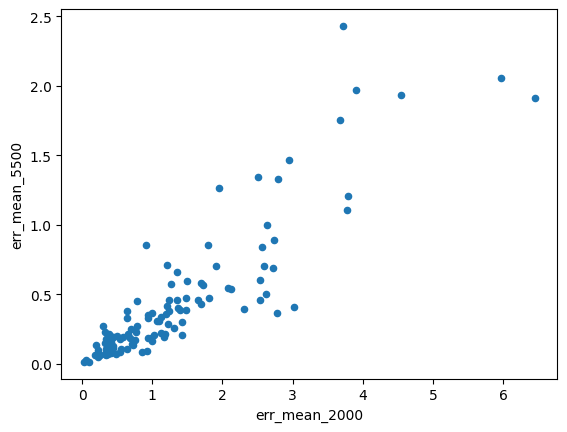

In [10]:
df_merged.plot.scatter('err_mean_2000', 'err_mean_5500')

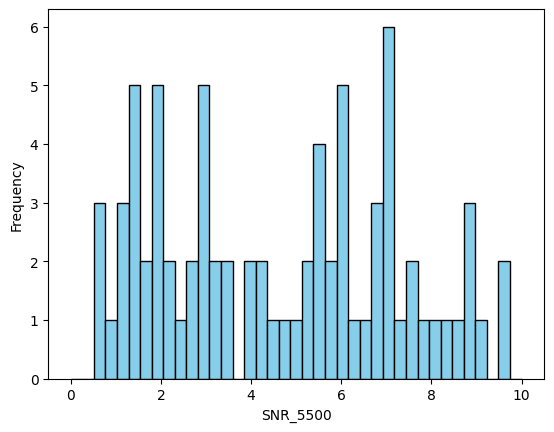

In [11]:
# Create the histogram
plt.hist(df_merged['SNR_5500'], bins=np.linspace(0, 10, 40), color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('SNR_5500')
plt.ylabel('Frequency')
#plt.title('')

plt.show()

### Filtros para SNR e erro em 5500

In [12]:
## objetos com SNR < 2
rfiltro_SNR_2 = df_merged['SNR_5500'] < 2
df_retirado_snr = df_merged[rfiltro_SNR_2]
df_retirado_snr


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,6368,160387,capers-cos13-v4,150.129404,2.393668,6.380030,0,None,None,None,None,4.507080,5.072039,6.081922,7.440252,8.931528,2.314057e+42,2.433602e+42,2.593018e+42,2.725515e+42,2.840988e+42,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.843015,42.880950,42.935501,42.976605,43.008053,4.263485e+41,3.549946
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,2750,2015,ceers-ddt-v4,214.917995,52.937245,4.892552,0,None,None,None,None,3.367964,3.691539,4.497423,5.548599,6.442166,6.127589e+41,6.269105e+41,6.510673e+41,6.755376e+41,6.947995e+41,2.435901e+41,2.538795e+41,2.748128e+41,2.951601e+41,3.077834e+41,42.349647,42.388176,42.441923,42.487981,42.516994,1.447645e+41,1.898343
24,cosmos-transients-v4_prism-clear_6585_65449.sp...,5.205048,True,4.477463e-21,0.3446,0.3646,None,1.024578,1.006113,0.449430,0.605267,0.969053,2.535839,0.742532,6585,65449,cosmos-transients-v4,150.132193,2.380441,5.205048,0,None,None,None,None,2.169308,2.435258,3.138650,4.445870,5.636867,5.198822e+41,5.431452e+41,5.845773e+41,6.319185e+41,6.598537e+41,2.820122e+41,3.045672e+41,3.390018e+41,3.668316e+41,3.887275e+41,42.546279,42.601386,42.688712,42.784496,42.847047,1.862512e+41,1.820132
54,macs0416-v4_prism-clear_1208_3104219.spec.fits,6.414142,True,8.517997e-21,0.3446,0.3646,None,1.035353,1.031689,1.276079,0.999825,4.046941,2.639844,1.276303,1208,3104219,macs0416-v4,64.068374,-24.112313,6.414142,0,None,None,None,None,2.751929,3.035754,3.500697,3.993963,4.497599,2.371288e+42,2.487170e+42,2.674917e+42,2.926304e+42,3.105929e+42,2.537505e+42,2.613524e+42,2.735085e+42,2.857748e+42,2.956066e+42,43.285952,43.316719,43.358083,43.397743,43.419444,7.641099e+41,3.579440
55,macs0417-v4_prism-clear_1208_205006.spec.fits,5.621284,True,8.924223e-21,0.3446,0.3646,None,0.898028,0.898843,0.366699,0.706677,1.402662,1.911706,0.518905,1208,205006,macs0417-v4,64.376038,-11.798177,5.621284,0,None,None,None,None,2.857436,3.587554,5.824492,10.826982,18.453074,5.047824e+41,5.452372e+41,6.096983e+41,6.810487e+41,7.377631e+41,3.745300e+41,4.097313e+41,4.728704e+41,5.287770e+41,5.696935e+41,42.678906,42.742929,42.846120,42.930928,42.964156,1.046784e+41,4.517366
57,macs1423-v4_prism-clear_1208_4111584.spec.fits,4.065684,True,7.675337e-21,0.3446,0.3646,None,0.881759,0.886041,0.712632,0.456509,2.709648,2.535624,1.561049,1208,4111584,macs1423-v4,215.929628,24.108352,4.065684,0,None,None,None,None,2.757420,3.064270,3.868951,5.154250,6.553924,5.984846e+41,6.241603e+41,6.577310e+41,6.956963e+41,7.226033e+41,2.384529e+41,2.609846e+41,2.966813e+41,3.301996e+41,3.505928e+41,42.528239,42.560162,42.607503,42.647398,42.676150,1.700024e+41,1.745160
61,nexus-obs3-v4_prism-clear_5105_12143.spec.fits,5.867350,True,1.970059e-20,0.3446,0.3646,None,0.672495,0.654349,0.867351,0.594056,2.202868,1.494477,1.460051,5105,12143,nexus-obs3-v4,268.428339,65.173502,5.867350,0,None,None,None,None,7.808856,8.280039,9.355849,10.853805,11.979954,1.350364e+43,1.373511e+43,1.406346e+43,1.438284e+43,1.460664e+43,4.519632e+42,4.631840e+42,4.789143e+42,4.968273e+42,5.082681e+42,43.379263,43.420252,43.463742,43.513858,43.542947,1.503173e+42,3.186023
69,rubies-egs51-v4_prism-clear_4233_92

In [13]:
## objetos com erro em 5500 > 1.1
rfiltro_5500 = df_merged['err_mean_5500'] > 1.1
df_retirado_5500 = df_merged[rfiltro_5500]
df_retirado_5500


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,2750,2015,ceers-ddt-v4,214.917995,52.937245,4.892552,0,None,None,None,None,3.367964,3.691539,4.497423,5.548599,6.442166,6.127589e+41,6.269105e+41,6.510673e+41,6.755376e+41,6.947995e+41,2.435901e+41,2.538795e+41,2.748128e+41,2.951601e+41,3.077834e+41,42.349647,42.388176,42.441923,42.487981,42.516994,1.447645e+41,1.898343
20,ceers-v4_prism-clear_1345_746.spec.fits,5.629804,True,3.585568e-21,0.3446,0.3646,None,1.547016,1.546700,3.278298,1.208082,1.244470,3.794465,2.713638,1345,746,ceers-v4,214.809142,52.868484,5.629804,0,None,None,None,None,8.627926,9.546990,10.793353,12.887949,14.509414,2.788223e+42,2.838741e+42,2.913706e+42,2.999832e+42,3.048325e+42,6.331812e+41,6.491131e+41,6.769001e+41,7.119539e+41,7.311684e+41,43.137026,43.156003,43.184255,43.208891,43.224862,2.699537e+41,2.507467
27,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,6.686174,True,4.603297e-21,0.3446,0.3646,None,1.250503,1.246891,5.933729,1.326901,3.051061,2.790121,4.471870,4106,57146,egs-nelsonx-v4,214.892246,52.877410,6.686174,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None,13.359814,13.854294,14.868699,16.113110,16.830442,1.940617e+43,1.959313e+43,1.983133e+43,2.007451e+43,2.025017e+43,1.317927e+42,1.355726e+42,1.414502e+42,1.484999e+42,1.516958e+42,43.782220,43.788835,43.800713,43.811823,43.817567,1.333763e+42,1.060534
29,egs-nelsonx-v4_prism-clear_4106_85168.spec.fits,7.769293,True,3.448394e-21,0.3446,0.3646,None,0.811399,0.807965,2.545233,1.264270,2.881953,1.957825,2.013205,4106,85168,egs-nelsonx-v4,214.830660,52.887775,7.769293,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.268183e+41,5.543233e+41,5.936633e+41,6.322696e+41,6.586532e+41,43.373148,43.386926,43.409427,43.428733,43.444718,NaN,NaN
41,jades-gdn11-v4_prism-clear_1181_4685.spec.fits,7.415902,True,2.252017e-21,0.3446,0.3646,None,1.666005,1.667775,5.628962,2.431623,5.814549,3.720818,2.314899,1181,4685,jades-gdn11-v4,189.096293,62.239144,7.415902,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.970908e+41,5.298448e+41,5.795439e+41,6.282995e+41,6.672629e+41,43.580929,43.593546,43.610988,43.625374,43.634526,NaN,NaN
59,nexus-obs3-v4_prism-clear_5105_10835.spec.fits,4.650120,True,4.304812e-21,0.3446,0.3646,None,2.717814,2.666168,8.037268,2.055827,7.560083,5.972079,3.909505,5105,10835,nexus-obs3-v4,268.437675,65.167485,4.650120,0,None,None,None,None,10.503712,11.217625,12.781884,14.633585,16.275463,1.250773e+43,1.267096e+43,1.295340e+43,1.320482e+43,1.337731e+43,1.347500e+42,1.404370e+42,1.503070e+42,1.584932e+42,1.638910e+42,43.557779,43.566198,43.581210,43.594781,43.604914,1.013419e+42,1.483168
75,rubies-egs61-v4_prism-clear_4233_952625.spec.fits,5.108550,True,2.451059e-21,0.3446,0.3646,None,2.937422,2.882887,1.689634,1.914472,1.373386,6.448253,0.882559,4233,952625,rubies-egs61-v4,214.975529,52.925268,5.108550,0,None,None,None,None,4.228152,4.944182,6.683724,9.889689,14.036601,6.963224e+41,7.360245e+41,7.895805e+41,8.540317e+41,8.914574e+41,4.993569e+41,5.205674e+41,5.568279e+41,5.910166e+41,6.110481e+41,42.732070,42.782776,42.868925,42.944614,42.982469,1.181348e+41,4.713495
81,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,7.151696,True,4.862566e-21,0

In [14]:
## dataframe final dos objetos retirados 
df_retirado = df_merged[rfiltro_SNR_2 | rfiltro_5500]
df_retirado

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
4,capers-cos13-v4_prism-clear_6368_160387.spec.fits,6.380030,True,4.224238e-21,0.3446,0.3646,None,1.021989,1.001146,0.934393,0.892531,3.248987,2.730229,1.046903,6368,160387,capers-cos13-v4,150.129404,2.393668,6.380030,0,None,None,None,None,4.507080,5.072039,6.081922,7.440252,8.931528,2.314057e+42,2.433602e+42,2.593018e+42,2.725515e+42,2.840988e+42,1.406226e+42,1.450743e+42,1.513514e+42,1.583113e+42,1.627397e+42,42.843015,42.880950,42.935501,42.976605,43.008053,4.263485e+41,3.549946
19,ceers-ddt-v4_prism-clear_2750_2015.spec.fits,4.892552,True,1.566177e-21,0.3446,0.3646,None,1.659204,1.641548,1.612301,1.109079,3.848120,3.772544,1.453730,2750,2015,ceers-ddt-v4,214.917995,52.937245,4.892552,0,None,None,None,None,3.367964,3.691539,4.497423,5.548599,6.442166,6.127589e+41,6.269105e+41,6.510673e+41,6.755376e+41,6.947995e+41,2.435901e+41,2.538795e+41,2.748128e+41,2.951601e+41,3.077834e+41,42.349647,42.388176,42.441923,42.487981,42.516994,1.447645e+41,1.898343
20,ceers-v4_prism-clear_1345_746.spec.fits,5.629804,True,3.585568e-21,0.3446,0.3646,None,1.547016,1.546700,3.278298,1.208082,1.244470,3.794465,2.713638,1345,746,ceers-v4,214.809142,52.868484,5.629804,0,None,None,None,None,8.627926,9.546990,10.793353,12.887949,14.509414,2.788223e+42,2.838741e+42,2.913706e+42,2.999832e+42,3.048325e+42,6.331812e+41,6.491131e+41,6.769001e+41,7.119539e+41,7.311684e+41,43.137026,43.156003,43.184255,43.208891,43.224862,2.699537e+41,2.507467
24,cosmos-transients-v4_prism-clear_6585_65449.sp...,5.205048,True,4.477463e-21,0.3446,0.3646,None,1.024578,1.006113,0.449430,0.605267,0.969053,2.535839,0.742532,6585,65449,cosmos-transients-v4,150.132193,2.380441,5.205048,0,None,None,None,None,2.169308,2.435258,3.138650,4.445870,5.636867,5.198822e+41,5.431452e+41,5.845773e+41,6.319185e+41,6.598537e+41,2.820122e+41,3.045672e+41,3.390018e+41,3.668316e+41,3.887275e+41,42.546279,42.601386,42.688712,42.784496,42.847047,1.862512e+41,1.820132
27,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,6.686174,True,4.603297e-21,0.3446,0.3646,None,1.250503,1.246891,5.933729,1.326901,3.051061,2.790121,4.471870,4106,57146,egs-nelsonx-v4,214.892246,52.877410,6.686174,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None,13.359814,13.854294,14.868699,16.113110,16.830442,1.940617e+43,1.959313e+43,1.983133e+43,2.007451e+43,2.025017e+43,1.317927e+42,1.355726e+42,1.414502e+42,1.484999e+42,1.516958e+42,43.782220,43.788835,43.800713,43.811823,43.817567,1.333763e+42,1.060534
29,egs-nelsonx-v4_prism-clear_4106_85168.spec.fits,7.769293,True,3.448394e-21,0.3446,0.3646,None,0.811399,0.807965,2.545233,1.264270,2.881953,1.957825,2.013205,4106,85168,egs-nelsonx-v4,214.830660,52.887775,7.769293,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.268183e+41,5.543233e+41,5.936633e+41,6.322696e+41,6.586532e+41,43.373148,43.386926,43.409427,43.428733,43.444718,NaN,NaN
41,jades-gdn11-v4_prism-clear_1181_4685.spec.fits,7.415902,True,2.252017e-21,0.3446,0.3646,None,1.666005,1.667775,5.628962,2.431623,5.814549,3.720818,2.314899,1181,4685,jades-gdn11-v4,189.096293,62.239144,7.415902,0,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.970908e+41,5.298448e+41,5.795439e+41,6.282995e+41,6.672629e+41,43.580929,43.593546,43.610988,43.625374,43.634526,NaN,NaN
54,macs0416-v4_prism-clear_1208_3104219.spec.fits,6.414142,True,8.517997e-21,0.

In [15]:
## -------- Dataframe com objetos que passam nos filtros de SNR e erro em 5500 ---------

filtro_SNR_2 = df_merged['SNR_5500'] > 2
filtro_5500 = df_merged['err_mean_5500'].between(0, 1.1)
df_filtrado = df_merged[filtro_SNR_2 & filtro_5500]
df_filtrado


,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,7.660733,7.854381,8.131770,8.423320,8.642884,5.668301e+42,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709
2,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,7.001882,7.347297,7.822455,8.356926,8.722397,2.825816e+42,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020
3,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,3.211496,3.408269,3.710558,4.025521,4.282236,7.447690e+41,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764
5,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,6368,4771,capers-cos19-v4,150.161029,2.465804,5.927350,0,None,None,None,None,7.565332,7.908462,8.432724,8.989159,9.396065,6.036184e+42,6.100056e+42,6.192903e+42,6.303222e+42,6.357122e+42,1.246757e+42,1.271856e+42,1.304910e+42,1.339891e+42,1.361390e+42,43.129767,43.145293,43.162038,43.180440,43.189226,7.343895e+41,1.776863
6,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,6368,9226,capers-cos19-v4,150.175938,2.432430,3.724103,0,None,None,None,None,10.322535,10.786400,11.570909,12.370488,13.004778,1.198086e+43,1.209660e+43,1.228081e+43,1.247075e+43,1.259925e+43,6.222170e+42,6.279176e+42,6.369545e+42,6.459206e+42,6.515543e+42,43.595210,43.599419,43.605356,43.611473,43.615556,1.061352e+42,6.001349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,6.466503,6.709816,7.383194,8.051341,8.612028,2.859931e+42,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110
117,uncover-v4_prism-clear_2561_38108.spec.fits,4.968462,True,1.528527e-20,0.3446,0.3646,None,0.178484,0.181363,1.180107,0.116120,3.188791,0.417475,10.162803,2561,38108,uncover-v4,3.530009,-30.358013,4.968462,0,None,None,None,None,9.274564,9.682999,10.321250,11.320986,11.932840,5.628233e+42,5.667344e+42,5.734779e+42,5.796238e+42,5.

### Verificando espectros duplicados



In [16]:
# ----- visualizando os objetos com espectros duplicados -----
df_filtrado[df_filtrado['Ndup'] != 0]

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb
7,capers-egs47-v4_prism-clear_6368_19300.spec.fits,4.533263,True,1.391252e-20,0.3446,0.3646,None,0.192967,0.189457,1.486142,0.117289,3.467779,0.439656,12.670799,6368,19300,capers-egs47-v4,215.022070,52.920786,4.533263,1,capers-egs47-v4_prism-clear_6368_19300.spec.fits,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,None,None,10.096180,10.508445,11.355898,12.225435,12.911068,5.979157e+42,6.029228e+42,6.089302e+42,6.152468e+42,6.191094e+42,7.720190e+41,7.882330e+41,8.138622e+41,8.404580e+41,8.576070e+41,43.313952,43.317367,43.321919,43.327177,43.330973,5.362238e+41,1.517766
9,capers-egs49-v4_prism-clear_6368_11585.spec.fits,6.695822,True,2.656022e-20,0.3446,0.3646,None,0.110287,0.105460,3.112701,0.136405,1.620195,0.205848,22.819552,6368,11585,capers-egs49-v4,214.892249,52.877403,6.695822,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None,7.556281,7.733102,8.031414,8.327022,8.534577,4.689615e+43,4.710011e+43,4.743479e+43,4.779119e+43,4.799995e+43,4.939462e+42,5.045886e+42,5.211409e+42,5.358105e+42,5.492423e+42,44.335176,44.336847,44.338743,44.340634,44.341969,5.906156e+42,0.882369
13,capers-egs65-v4_prism-clear_6368_14197.spec.fits,7.152932,True,3.291381e-21,0.3446,0.3646,None,0.578135,0.572609,4.542776,0.708737,3.010269,1.213369,6.409679,6368,14197,capers-egs65-v4,214.929510,52.887912,7.152932,1,capers-egs65-v4_prism-clear_6368_14197.spec.fits,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,None,None,14.072253,14.824628,16.097087,17.553794,18.671951,8.073520e+42,8.188316e+42,8.331473e+42,8.494542e+42,8.590101e+42,6.952118e+41,7.111630e+41,7.414618e+41,7.747015e+41,7.956824e+41,43.613213,43.619129,43.625879,43.632588,43.636683,5.175764e+41,1.432565
14,capers-egs65-v4_prism-clear_6368_19799.spec.fits,4.223552,True,1.701345e-20,0.3446,0.3646,None,0.231135,0.231857,3.324051,0.177694,1.983190,0.545464,18.706622,6368,19799,capers-egs65-v4,214.924146,52.849047,4.223552,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None,8.751064,9.377636,10.455018,11.999495,12.984116,6.175607e+42,6.246849e+42,6.342543e+42,6.436925e+42,6.487002e+42,1.418447e+42,1.452641e+42,1.505926e+42,1.564235e+42,1.593791e+42,43.666131,43.668717,43.673089,43.677220,43.680594,6.066506e+41,2.482361
15,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,5.516014,True,2.760887e-20,0.3446,0.3646,None,0.144757,0.146432,1.505929,0.109224,2.475004,0.344184,13.787496,6368,23419,capers-udsp1-v4,34.471107,-5.190455,5.516014,1,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,None,None,8.692545,8.798963,9.091635,9.380625,9.627613,2.007292e+43,2.015861e+43,2.031237e+43,2.046975e+43,2.057411e+43,3.617650e+42,3.648869e+42,3.704685e+42,3.759869e+42,3.789927e+42,43.839658,43.841842,43.846057,43.849491,43.852078,2.234182e+42,1.658184
21,ceers-v4_prism-clear_1345_80457.spec.fits,4.222574,True,5.524952e-21,0.3446,0.3646,None,1.157671,1.108955,5.428549,0.701343,2.334325,2.594080,7.740215,1345,80457,ceers-v4,214.924125,52.849047,4.222574,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None,14.750198,16.546435,21.384426,30.125423,40.347046,2.833352e+42,2.869851e+42,2.938141e+42,3.009289e+42,3.04829

In [17]:
## função para selecionar o espectro com melhor SNR entre os duplicados

def select_best_snr(df):
    df = df.copy()

    # colunas de duplicados
    dup_cols = [col for col in df.columns if col.startswith('dup_filenames')]

    # criar lista de arquivos por linha
    def build_group(row):
        files = [row['file']]
        
        for col in dup_cols:
            if pd.notna(row[col]):
                files.append(row[col])
        
        # remover duplicados e ordenar
        files = sorted(set(files))
        
        return tuple(files)

    df['group_id'] = df.apply(build_group, axis=1)

    # selecionar o maior SNR em cada grupo
    idx = df.groupby('group_id')['SNR_5500'].idxmax()

    df_best = df.loc[idx].reset_index(drop=True)

    return df_best

In [18]:
# Dataframe final com os melhores espectros entre os duplicados

df_best = select_best_snr(df_filtrado)
df_best

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,7.660733,7.854381,8.131770,8.423320,8.642884,5.668301e+42,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709,"(None, capers-cos07-v4_prism-clear_6368_43711...."
1,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,7.001882,7.347297,7.822455,8.356926,8.722397,2.825816e+42,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020,"(None, capers-cos10-v4_prism-clear_6368_30440...."
2,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,3.211496,3.408269,3.710558,4.025521,4.282236,7.447690e+41,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764,"(None, capers-cos10-v4_prism-clear_6368_32659...."
3,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,6368,4771,capers-cos19-v4,150.161029,2.465804,5.927350,0,None,None,None,None,7.565332,7.908462,8.432724,8.989159,9.396065,6.036184e+42,6.100056e+42,6.192903e+42,6.303222e+42,6.357122e+42,1.246757e+42,1.271856e+42,1.304910e+42,1.339891e+42,1.361390e+42,43.129767,43.145293,43.162038,43.180440,43.189226,7.343895e+41,1.776863,"(None, capers-cos19-v4_prism-clear_6368_4771.s..."
4,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,6368,9226,capers-cos19-v4,150.175938,2.432430,3.724103,0,None,None,None,None,10.322535,10.786400,11.570909,12.370488,13.004778,1.198086e+43,1.209660e+43,1.228081e+43,1.247075e+43,1.259925e+43,6.222170e+42,6.279176e+42,6.369545e+42,6.459206e+42,6.515543e+42,43.595210,43.599419,43.605356,43.611473,43.615556,1.061352e+42,6.001349,"(None, capers-cos19-v4_prism-clear_6368_9226.s..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,6.466503,6.709816,7.383194,8.051341,8.612028,2.859931e+42,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110,"(None, uncover-v4_prism-clear_2561_28876.spec...."
71,uncove

In [19]:
# ----- visualizando os objetos com espectros duplicados -----
df_best[df_best['Ndup'] != 0]

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id
5,capers-egs47-v4_prism-clear_6368_19300.spec.fits,4.533263,True,1.391252e-20,0.3446,0.3646,None,0.192967,0.189457,1.486142,0.117289,3.467779,0.439656,12.670799,6368,19300,capers-egs47-v4,215.022070,52.920786,4.533263,1,capers-egs47-v4_prism-clear_6368_19300.spec.fits,rubies-egs52-v4_prism-clear_4233_29489.spec.fits,None,None,10.096180,10.508445,11.355898,12.225435,12.911068,5.979157e+42,6.029228e+42,6.089302e+42,6.152468e+42,6.191094e+42,7.720190e+41,7.882330e+41,8.138622e+41,8.404580e+41,8.576070e+41,43.313952,43.317367,43.321919,43.327177,43.330973,5.362238e+41,1.517766,"(None, capers-egs47-v4_prism-clear_6368_19300...."
7,capers-egs49-v4_prism-clear_6368_11585.spec.fits,6.695822,True,2.656022e-20,0.3446,0.3646,None,0.110287,0.105460,3.112701,0.136405,1.620195,0.205848,22.819552,6368,11585,capers-egs49-v4,214.892249,52.877403,6.695822,2,capers-egs49-v4_prism-clear_6368_11585.spec.fits,rubies-egs63-v4_prism-clear_4233_49140.spec.fits,egs-nelsonx-v4_prism-clear_4106_57146.spec.fits,None,7.556281,7.733102,8.031414,8.327022,8.534577,4.689615e+43,4.710011e+43,4.743479e+43,4.779119e+43,4.799995e+43,4.939462e+42,5.045886e+42,5.211409e+42,5.358105e+42,5.492423e+42,44.335176,44.336847,44.338743,44.340634,44.341969,5.906156e+42,0.882369,"(None, capers-egs49-v4_prism-clear_6368_11585...."
11,capers-egs65-v4_prism-clear_6368_14197.spec.fits,7.152932,True,3.291381e-21,0.3446,0.3646,None,0.578135,0.572609,4.542776,0.708737,3.010269,1.213369,6.409679,6368,14197,capers-egs65-v4,214.929510,52.887912,7.152932,1,capers-egs65-v4_prism-clear_6368_14197.spec.fits,rubies-egs63-v4_prism-clear_4233_42803.spec.fits,None,None,14.072253,14.824628,16.097087,17.553794,18.671951,8.073520e+42,8.188316e+42,8.331473e+42,8.494542e+42,8.590101e+42,6.952118e+41,7.111630e+41,7.414618e+41,7.747015e+41,7.956824e+41,43.613213,43.619129,43.625879,43.632588,43.636683,5.175764e+41,1.432565,"(None, capers-egs65-v4_prism-clear_6368_14197...."
12,capers-egs65-v4_prism-clear_6368_19799.spec.fits,4.223552,True,1.701345e-20,0.3446,0.3646,None,0.231135,0.231857,3.324051,0.177694,1.983190,0.545464,18.706622,6368,19799,capers-egs65-v4,214.924146,52.849047,4.223552,2,capers-egs65-v4_prism-clear_6368_19799.spec.fits,rubies-egs63-v4_prism-clear_4233_28812.spec.fits,ceers-v4_prism-clear_1345_80457.spec.fits,None,8.751064,9.377636,10.455018,11.999495,12.984116,6.175607e+42,6.246849e+42,6.342543e+42,6.436925e+42,6.487002e+42,1.418447e+42,1.452641e+42,1.505926e+42,1.564235e+42,1.593791e+42,43.666131,43.668717,43.673089,43.677220,43.680594,6.066506e+41,2.482361,"(None, capers-egs65-v4_prism-clear_6368_19799...."
13,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,5.516014,True,2.760887e-20,0.3446,0.3646,None,0.144757,0.146432,1.505929,0.109224,2.475004,0.344184,13.787496,6368,23419,capers-udsp1-v4,34.471107,-5.190455,5.516014,1,gto-wide-uds11-v4_prism-clear_1215_4994.spec.fits,capers-udsp1-v4_prism-clear_6368_23419.spec.fits,None,None,8.692545,8.798963,9.091635,9.380625,9.627613,2.007292e+43,2.015861e+43,2.031237e+43,2.046975e+43,2.057411e+43,3.617650e+42,3.648869e+42,3.704685e+42,3.759869e+42,3.789927e+42,43.839658,43.841842,43.846057,43.849491,43.852078,2.234182e+42,1.658184,"(None, capers-udsp1-v4_prism-clear_6368_23419...."
19,egs-nelsonx-v4_prism-clear_4106_47962.spec.fits,6.728559,True,1.886419e-20,0.3446,0.3646,None,0.156403,0.153602,1.110839,0.162247,2.776683,0.381259,6.846605,4106,47962,egs-nelsonx-v4,214.8

## Visualizando os dados limpos

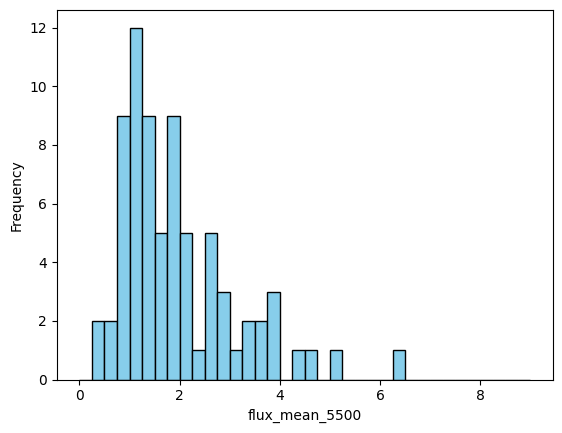

In [20]:
# Create the histogram
plt.hist(df_best['flux_mean_5500'], bins=np.linspace(0, 9, 37), color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('flux_mean_5500')
plt.ylabel('Frequency')
#plt.title('')

plt.show()

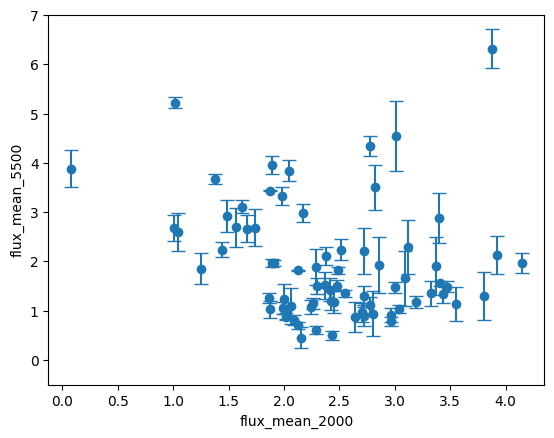

In [21]:
plt.errorbar(df_best['flux_mean_2000'], df_best['flux_mean_5500'], yerr=df_best['err_mean_5500'], #xerr=df_best['err_mean_2000'], 
             fmt='o', capsize=5)
plt.ylim(-0.5,7)
plt.xlabel('flux_mean_2000')
plt.ylabel('flux_mean_5500')
plt.show()

## Definindo os grupos

In [22]:
bins = [0, 1.25, 2.5, 3.75, 5, 18.5]
labels = ["G1", "G2", "G3", "G4", 'G5']

df_best['grupos'] = pd.cut(df_best['flux_mean_5500'], bins=bins, labels=labels)

df_best["grupos"].value_counts()

grupos
G2    29
G1    25
G3    13
G4     5
G5     3
Name: count, dtype: int64

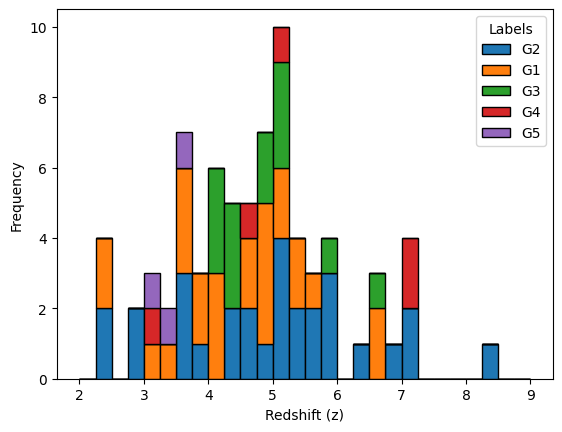

In [23]:
# Separar os dados por grupo (label)
grupos = df_best['grupos'].unique()
dados_por_grupo = [df_best[df_best['grupos'] == grupo]['z'] for grupo in grupos]


# Create the histogram
plt.hist(dados_por_grupo, bins=np.linspace(2, 9, 29), stacked=True, label=grupos, edgecolor='black')

# Add labels and title
plt.xlabel('Redshift (z)')
plt.ylabel('Frequency')
plt.legend(title='Labels')
#plt.title('')

plt.show()

In [24]:

df_best["grupo_num"] = df_best["grupos"].map({
    "G1": 1,
    "G2": 2,
    "G3": 3,
    "G4": 4,
    "G5": 5
})

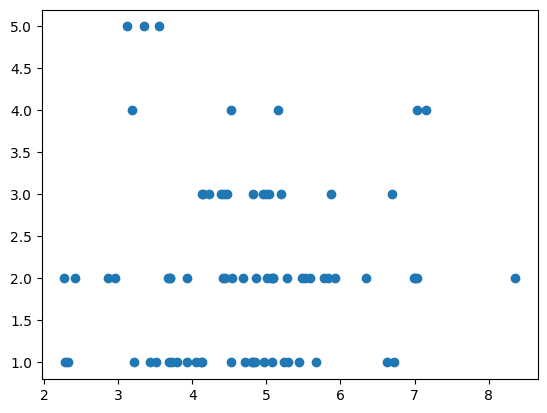

In [25]:

plt.scatter(df_best['z'], df_best['grupo_num'])
plt.show()

### Casos especiais

In [26]:
linhas_a = df_best[df_best['grupos'] == 'G5']
linhas_a

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id,grupos,grupo_num
54,rubies-uds1-v4_prism-clear_4233_40579.spec.fits,3.113558,True,7.074874e-20,0.3446,0.3646,None,0.119387,0.120747,5.218966,0.110583,1.018880,0.392648,47.195155,4233,40579,rubies-uds1-v4,34.244200,-5.245871,3.113558,0,None,None,None,None,12.279411,12.635565,13.205607,13.920013,14.313920,4.483146e+43,4.543663e+43,4.655959e+43,4.759668e+43,4.844298e+43,3.359958e+42,3.419979e+42,3.527484e+42,3.635885e+42,3.708407e+42,44.134391,44.135682,44.137541,44.139511,44.140998,3.525744e+42,1.000493,"(None, rubies-uds1-v4_prism-clear_4233_40579.s...",G5,5
58,rubies-uds23-v4_prism-clear_4233_144195.spec.fits,3.354755,True,1.154061e-20,0.3446,0.3646,None,0.748337,0.724885,6.316134,0.397383,3.880742,2.308169,15.894337,4233,144195,rubies-uds23-v4,34.325156,-5.143685,3.354755,0,None,None,None,None,9.039901,10.203803,12.320652,15.072650,17.375897,2.511551e+42,2.537262e+42,2.574081e+42,2.615868e+42,2.641899e+42,1.058763e+41,1.288720e+41,1.620235e+41,1.969353e+41,2.172379e+41,43.543889,43.547674,43.553335,43.558839,43.561766,2.089241e+41,0.775514,"(None, rubies-uds23-v4_prism-clear_4233_144195...",G5,5
62,rubies-uds31-v4_prism-clear_4233_154183.spec.fits,3.548925,True,8.320946e-21,0.3446,0.3646,None,0.893270,0.884429,17.489988,0.686710,2.288155,2.714780,25.469251,4233,154183,rubies-uds31-v4,34.410749,-5.129664,3.548925,0,None,None,None,None,7.927115,8.443395,9.397890,10.621057,11.699576,6.521603e+42,6.575987e+42,6.643780e+42,6.704502e+42,6.754432e+42,3.871537e+40,7.096378e+40,1.127314e+41,1.648078e+41,2.030878e+41,43.890463,43.892740,43.895860,43.898783,43.900802,7.069438e+41,0.159463,"(None, rubies-uds31-v4_prism-clear_4233_154183...",G5,5


In [27]:
#new_cats = ['Outliers']
#df_best['grupos'] = df_best['grupos'].cat.add_categories(
#    [c for c in new_cats if c not in df_best['grupos'].cat.categories]
#)

## The Cliff
df_best.loc[df_best['file'] == 'rubies-uds31-v4_prism-clear_4233_154183.spec.fits', 'grupos'] = 'G5'

## uncover_2561_20698
df_best.loc[df_best['file'] == 'uncover-61-v4_prism-clear_2561_20698.spec.fits', 'grupos'] = 'G5'

df_best.loc[df_best['file'] == 'jades-gdn198-v4_prism-clear_1181_68797.spec.fits', 'grupos'] = 'G5'

df_best.loc[df_best['file'] == 'nexus-obs5-v4_prism-clear_5105_2314.spec.fits', 'grupos'] = 'G5'




In [28]:
df_best["grupos"].value_counts()

grupos
G2    28
G1    25
G3    11
G5     6
G4     5
Name: count, dtype: int64

### Listas dos grupos

In [29]:
g1_df = df_best[df_best['grupos']=='G1']
g2_df = df_best[df_best['grupos']=='G2']
g3_df = df_best[df_best['grupos']=='G3']
g4_df = df_best[df_best['grupos']=='G4']
g5_df = df_best[df_best['grupos']=='G5']


g1_zip = list(zip(g1_df['file'], g1_df['z']))
g2_zip = list(zip(g2_df['file'], g2_df['z']))
g3_zip = list(zip(g3_df['file'], g3_df['z']))
g4_zip = list(zip(g4_df['file'], g4_df['z']))
g5_zip = list(zip(g5_df['file'], g5_df['z']))


g1_zip_zsorted = sorted(g1_zip, key=lambda x: x[1])
g2_zip_zsorted = sorted(g2_zip, key=lambda x: x[1])
g3_zip_zsorted = sorted(g3_zip, key=lambda x: x[1])
g4_zip_zsorted = sorted(g4_zip, key=lambda x: x[1])
g5_zip_zsorted = sorted(g5_zip, key=lambda x: x[1])



In [30]:
## lista dos objetos com z < 2.5 para plotar os espectros
low_z = df_best[df_best['z'] < 2.5]
low_z_zip = list(zip(low_z['file'], low_z['z'])) 

## lista dos objetos com SNR < 2 ou erro em 5500 > 1.1 para plotar os espectros
ruido_zip = list(zip(df_retirado['file'], df_retirado['z']))

### Gráficos para os diferentes grupos

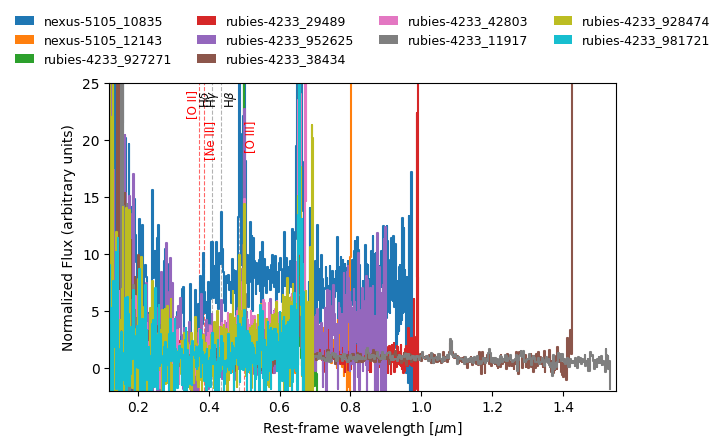

In [31]:
fig = plot_overlaid_spectra(
    ruido_zip,
    indices=range(10, 20),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

In [32]:
print(len(g1_zip_zsorted))

25


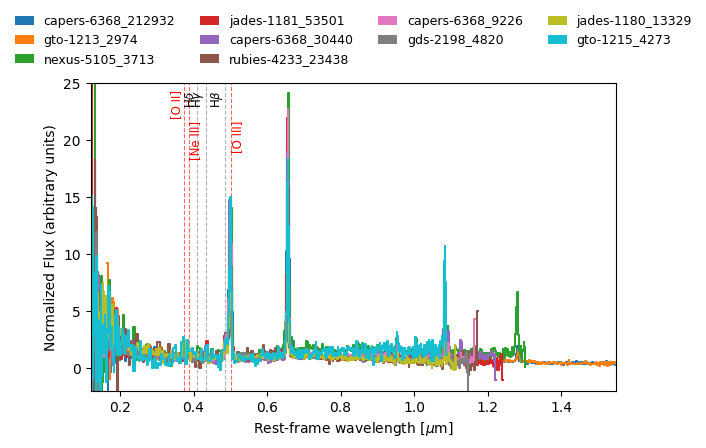

In [33]:
fig = plot_overlaid_spectra(
    g1_zip_zsorted,
    indices=range(0, 10),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

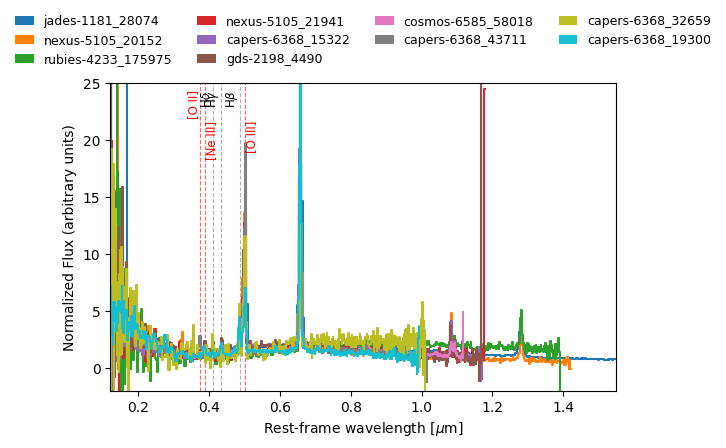

In [34]:
fig = plot_overlaid_spectra(
    g2_zip_zsorted,
    indices=range(0, 10),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

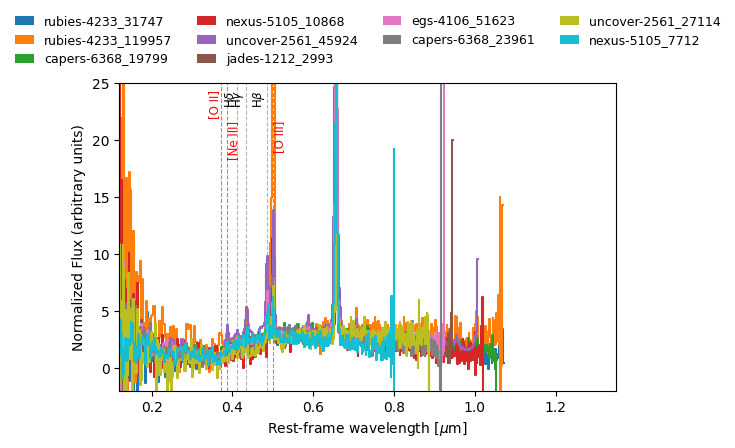

In [35]:
fig = plot_overlaid_spectra(
    g3_zip_zsorted, #+[('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 10),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.35),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

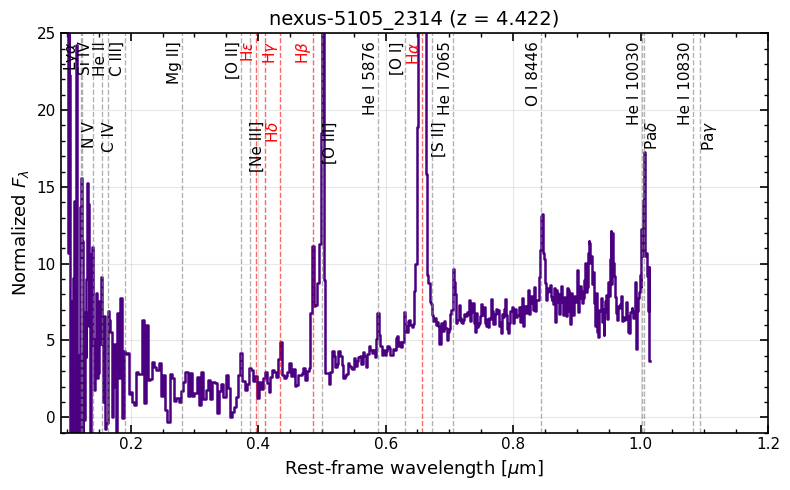

In [36]:
spec_gruopo3_1='jades-gdn-v4_prism-clear_1181_68797.spec.fits'
z_g3_1=5.043335

spec_grupo3_2='nexus-obs5-v4_prism-clear_5105_2314.spec.fits'
z_g3_2 = 4.42207

lines = {
    r"Ly$\alpha$": 0.121567,
    r"N V": 0.1240,
    r"Si IV": 0.140277,
    r"C IV": 0.1549,
    r"He II": 0.1640,
    r"C III]": 0.1909,
    r"Mg II]": 0.2800,
    r"[O II]": 0.3727,
    r"[Ne III]": 0.386876,
    r"H$\epsilon$": 0.3970079,
    r"H$\delta$": 0.4101742,
    r"H$\gamma$": 0.4340471,
    r"H$\beta$": 0.48613,
    r"[O III]": 0.5006843,
    r"He I 5876": 0.5875624,
    r"[O I]": 0.6300,
    r"H$\alpha$": 0.6563,
    r"[S II]": 0.6723,
    r"He I 7065": 0.7065,
    r"O I 8446": 0.8446,
    r"He I 10030": 1.0030,
    r"Pa$\delta$": 1.0049,
    r"He I 10830": 1.0830,
    r"Pa$\gamma$": 1.0938,
}

fig, ax = plot_spectrum_presentation(
    fname=spec_grupo3_2,
    z=z_g3_2,
    lines=lines,
    loader_kwargs=dict(normalize=True),
    spectrum_kwargs=dict(color='indigo', lw=1.8, where="mid"),
    xlim=(0.09,1.2),
    ylim=(-1,25)
)

fig.savefig('Figuras/jades-1180_12402.pdf')

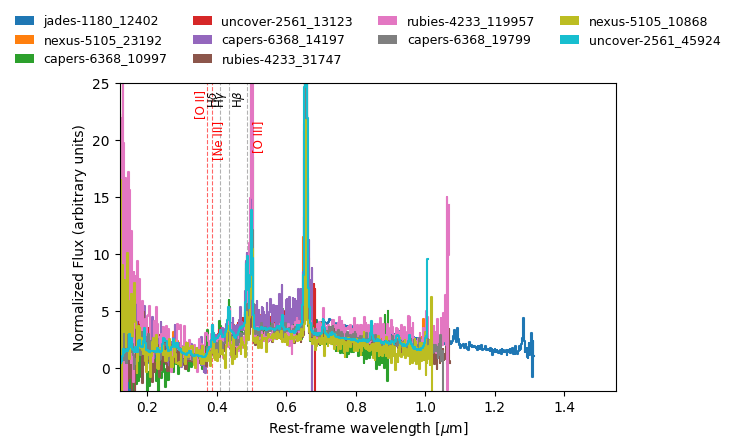

In [37]:
fig = plot_overlaid_spectra(
    g4_zip_zsorted + g3_zip_zsorted, #+ [('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 10),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.55),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

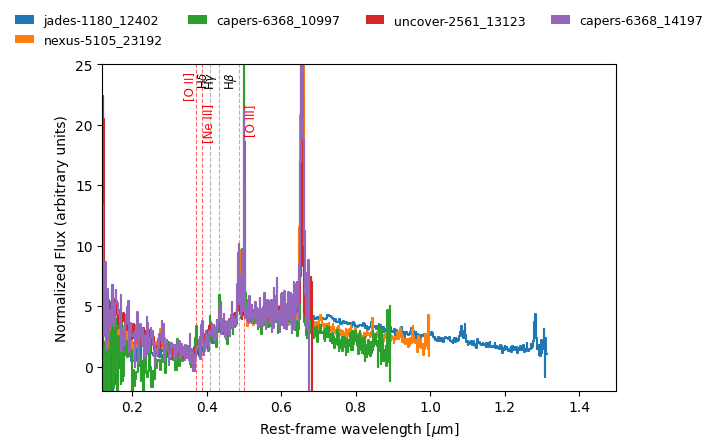

In [38]:
fig = plot_overlaid_spectra(
    g4_zip_zsorted, #+ g5_zip_zsorted, #+ [('uncover-61-v4_prism-clear_2561_20698.spec.fits',2.417316)],
    indices=range(0, 5),
    offset=False,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.5),
    ylim=(-2,25)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

[(np.str_('uncover-61-v4_prism-clear_2561_20698.spec.fits'), 2.417316), (np.str_('rubies-uds1-v4_prism-clear_4233_40579.spec.fits'), 3.113558), (np.str_('rubies-uds23-v4_prism-clear_4233_144195.spec.fits'), 3.3547552), (np.str_('rubies-uds31-v4_prism-clear_4233_154183.spec.fits'), 3.548925327627479), (np.str_('nexus-obs5-v4_prism-clear_5105_2314.spec.fits'), 4.42207), (np.str_('jades-gdn198-v4_prism-clear_1181_68797.spec.fits'), 5.0410485)]
[(np.str_('uncover-61-v4_prism-clear_2561_20698.spec.fits'), 2.417316), (np.str_('rubies-uds23-v4_prism-clear_4233_144195.spec.fits'), 3.3547552), (np.str_('rubies-uds1-v4_prism-clear_4233_40579.spec.fits'), 3.113558), (np.str_('nexus-obs5-v4_prism-clear_5105_2314.spec.fits'), 4.42207), (np.str_('jades-gdn198-v4_prism-clear_1181_68797.spec.fits'), 5.0410485), (np.str_('rubies-uds31-v4_prism-clear_4233_154183.spec.fits'), 3.548925327627479)]


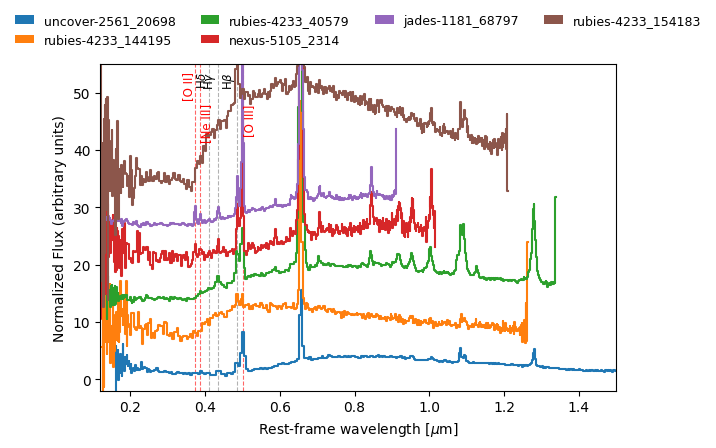

In [39]:
print(g5_zip_zsorted)

indices = [0,2,1,4,5,3]
reordenado = [g5_zip_zsorted[i] for i in indices]
print(reordenado)


fig = plot_overlaid_spectra(
    reordenado,
    indices=range(0, 6),
    offset=True,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.5),
    ylim=(-2,55)
)
#plt.savefig('exemplos_grupos/gx_0.pdf')
plt.show()

# Calculando o espectro médio de cada grupo

In [40]:
def build_mean_specs(
    grupos_dict,
    base_path="DeGraaff_espectros",
    n_clip_end=10,
    load_kwargs=None
):
    """
    Build mean spectra for multiple groups.

    Parameters
    ----------
    grupos_dict : dict
        {"G1": [(file, z), ...], "G2": [...], ...}
    load_kwargs : dict or None
        kwargs for load_spectrum()

    Returns
    -------
    mean_specs : dict
        {"G1": mean_spec, "G2": mean_spec, ...}
    """

    if load_kwargs is None:
        load_kwargs = dict(
            restframe=True,
            normalize=True,
            norm_window=(0.3446, 0.3646)
        )

    mean_specs = {}

    for nome, grupo in grupos_dict.items():

        spectra = []

        for file, z in grupo:
            try:
                spec = load_spectrum(
                    f"{base_path}/{file}",
                    z=z,
                    **load_kwargs
                )
                spectra.append(spec)

            except Exception as e:
                print(f"Skipping {file} → {e}")

        if len(spectra) == 0:
            print(f"{nome} vazio!")
            continue

        mean_spec = compute_mean_spectrum(
            spectra,
            n_clip_end=n_clip_end,
            flux_min=-2
        )

        mean_specs[nome] = mean_spec

        print(f"{nome}: N = {mean_spec['n_objects']}")

    return mean_specs

In [41]:
grupos = {
    "G1": g1_zip_zsorted,
    "G2": g2_zip_zsorted,
    "G3": g3_zip_zsorted,
    "G4": g4_zip_zsorted,
    #"G5": g5_zip_zsorted,
}

mean_specs = build_mean_specs(grupos)

G1: N = 25
G2: N = 28
G3: N = 11
G4: N = 5


/home/bruna-araujo/Documentos/LRDs/functions/spectrum.py:461: RuntimeWarning: Mean of empty slice
  flux_mean = np.nanmean(flux_stack, axis=0)
/home/bruna-araujo/Documentos/LRDs/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/bruna-araujo/Documentos/LRDs/functions/spectrum.py:485: RuntimeWarning: Mean of empty slice
  err_mean = np.sqrt(np.nanmean(err_stack**2, axis=0)) / np.sqrt(n_contrib)
/home/bruna-araujo/Documentos/LRDs/functions/spectrum.py:485: RuntimeWarning: divide by zero encountered in divide
  err_mean = np.sqrt(np.nanmean(err_stack**2, axis=0)) / np.sqrt(n_contrib)


In [42]:
grupo_outliers = {
    'G5': g5_zip_zsorted
}

outliers_mean = build_mean_specs(grupo_outliers)

G5: N = 6


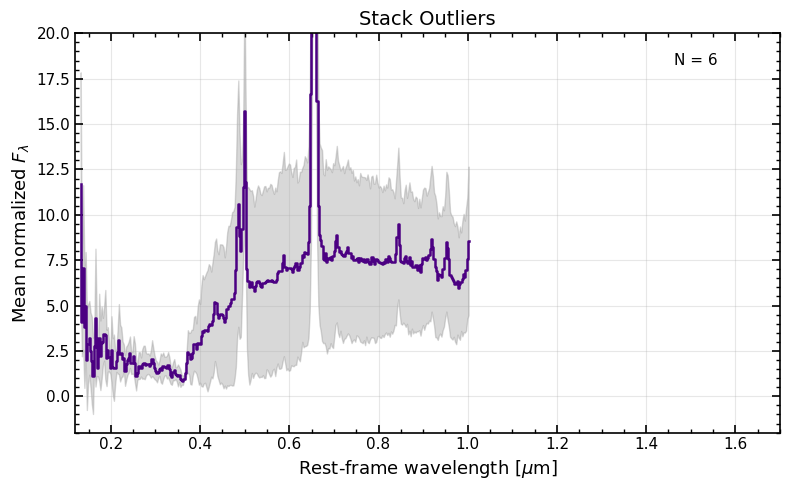

In [43]:
fig = plot_mean_spectrum(
    outliers_mean['G5'],
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack Outliers",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=5
)

#plt.savefig('Figuras/outliers_mean.pdf', bbox_inches='tight')
plt.show()

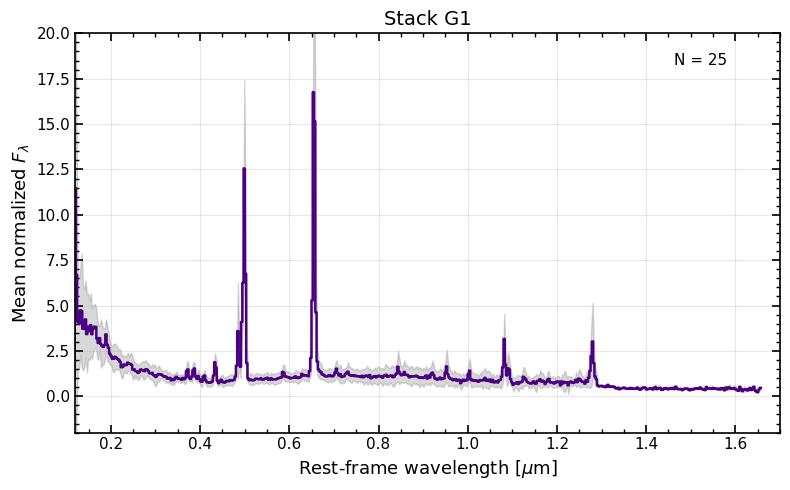

In [44]:
fig = plot_mean_spectrum(
    mean_specs['G1'],
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G1",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

#plt.savefig('Figuras/stack_G1.pdf', bbox_inches='tight')
plt.show()

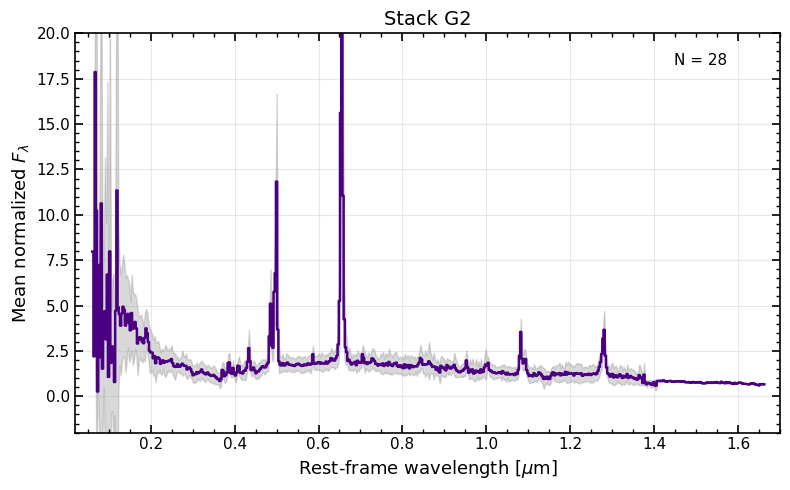

In [45]:
fig = plot_mean_spectrum(
    mean_specs['G2'],
    lines={},
    figsize=(8,5),
    xlim=(0.02, 1.7),
    ylim=(-2,20),
    title="Stack G2",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

#plt.savefig('Figuras/stack_G2.pdf', bbox_inches='tight')
plt.show()

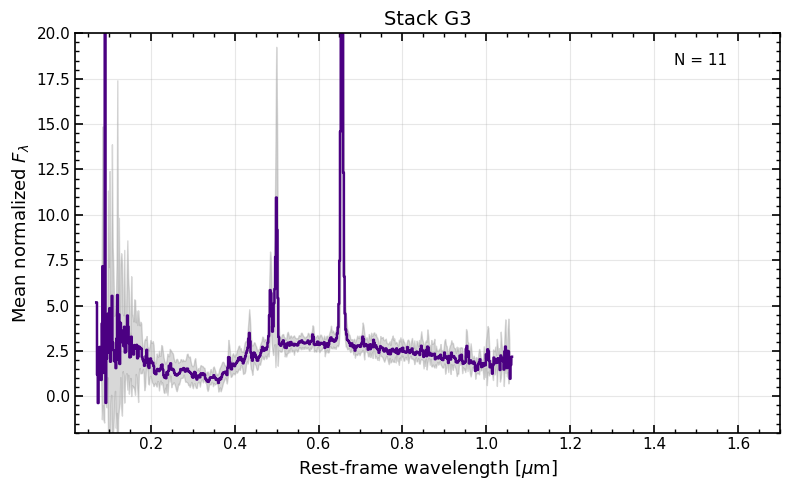

In [46]:
fig = plot_mean_spectrum(
    mean_specs['G3'],
    lines={},
    figsize=(8,5),
    xlim=(0.02, 1.7),
    ylim=(-2,20),
    title="Stack G3",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

#plt.savefig('Figuras/stack_G3.pdf', bbox_inches='tight')

plt.show()

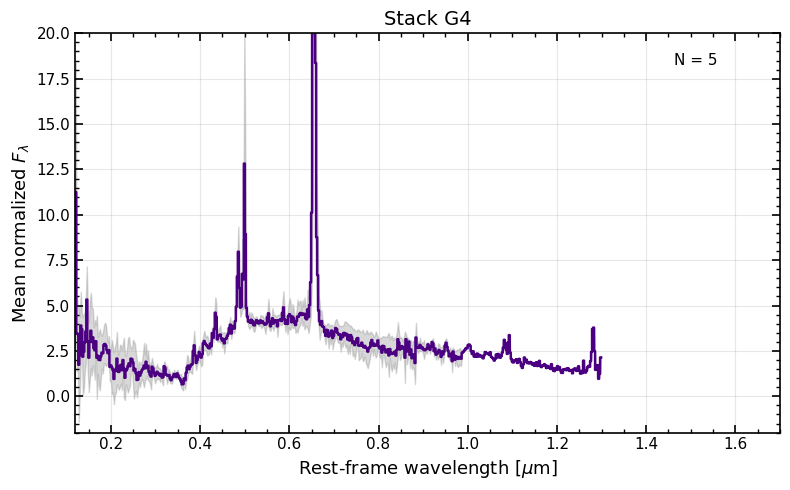

In [47]:
fig = plot_mean_spectrum(
    mean_specs['G4'],
    lines={},
    figsize=(8,5),
    xlim=(0.12, 1.7),
    ylim=(-2,20),
    title="Stack G4",
    spectrum_kwargs={"color": "indigo", "lw": 1.8},
    min_contrib=0
)

#plt.savefig('Figuras/stack_G4.pdf', bbox_inches='tight')
plt.show()

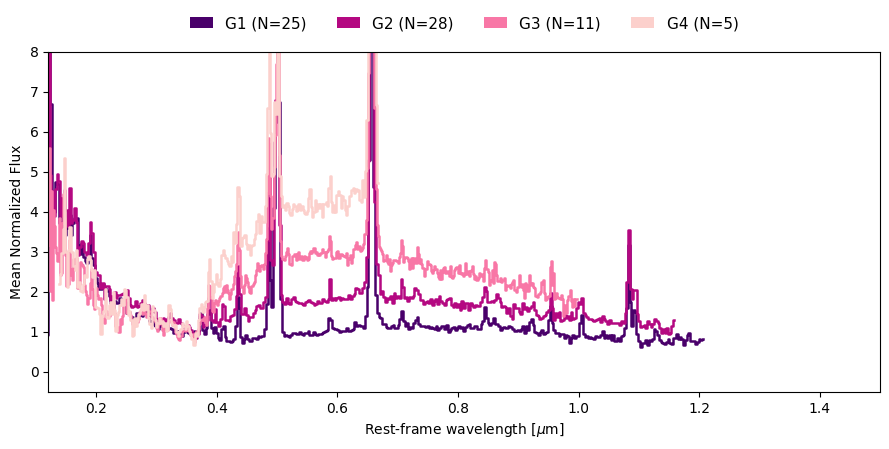

In [48]:
fig, ax = plot_overlaid_mean_spectra(
    mean_specs,
    offset=False,
    lines={},
    figsize=(9,5),
    min_contrib=5,
    ylim=(-0.5,8),
    xlim=(0.12,1.5)
)

## Escrever arquivos com os espectros médios

In [49]:

import os

def save_mean_specs_to_csv(
    mean_specs,
    output_dir="mean_spectra_csv",
    include_n_contrib=False,
    min_contrib=None
):
    """
    Save mean spectra to CSV files.

    Parameters
    ----------
    mean_specs : dict
        {"G1": mean_spec, "G2": ...}
    output_dir : str
        Directory to save files
    include_n_contrib : bool
        If True, also save number of contributors per pixel
    min_contrib : int or None
        Minimum number of contributing spectra per pixel
    """

    os.makedirs(output_dir, exist_ok=True)

    for name, mean_spec in mean_specs.items():

        wave = mean_spec["wave"]
        flux = mean_spec["flux_mean"]
        std  = mean_spec.get("flux_std")
        n_contrib = mean_spec.get("n_contrib")

        # -------------------------
        # aplicar corte de qualidade
        # -------------------------
        if min_contrib is not None and n_contrib is not None:
            mask = n_contrib >= min_contrib
        else:
            mask = np.ones_like(wave, dtype=bool)

        # aplicar máscara
        wave = wave[mask]
        flux = flux[mask]

        data = {
            "wave": wave,
            "flux": flux,
        }

        if std is not None:
            data["std"] = std[mask]

        if include_n_contrib and n_contrib is not None:
            data["n_contrib"] = n_contrib[mask]

        df = pd.DataFrame(data)

        filename = f"{name}_mean_spectrum.csv"
        filepath = os.path.join(output_dir, filename)

        df.to_csv(filepath, index=False)

        print(f"Saved: {filepath} ({mask.sum()} pixels)")

In [50]:
#save_mean_specs_to_csv(mean_specs, include_n_contrib=True, min_contrib=5)

In [51]:
#save_mean_specs_to_csv(outliers_mean,include_n_contrib=True, min_contrib=5)

# Calculando erros da tabela da de Graaff

In [52]:
df_best

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,Balmer_dec_total_0,Balmer_dec_total_1,Balmer_dec_total_2,Balmer_dec_total_3,Balmer_dec_total_4,LHa_total_0,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id,grupos,grupo_num
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,7.660733,7.854381,8.131770,8.423320,8.642884,5.668301e+42,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709,"(None, capers-cos07-v4_prism-clear_6368_43711....",G2,2
1,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,7.001882,7.347297,7.822455,8.356926,8.722397,2.825816e+42,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020,"(None, capers-cos10-v4_prism-clear_6368_30440....",G1,1
2,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,3.211496,3.408269,3.710558,4.025521,4.282236,7.447690e+41,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764,"(None, capers-cos10-v4_prism-clear_6368_32659....",G2,2
3,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,6368,4771,capers-cos19-v4,150.161029,2.465804,5.927350,0,None,None,None,None,7.565332,7.908462,8.432724,8.989159,9.396065,6.036184e+42,6.100056e+42,6.192903e+42,6.303222e+42,6.357122e+42,1.246757e+42,1.271856e+42,1.304910e+42,1.339891e+42,1.361390e+42,43.129767,43.145293,43.162038,43.180440,43.189226,7.343895e+41,1.776863,"(None, capers-cos19-v4_prism-clear_6368_4771.s...",G2,2
4,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,6368,9226,capers-cos19-v4,150.175938,2.432430,3.724103,0,None,None,None,None,10.322535,10.786400,11.570909,12.370488,13.004778,1.198086e+43,1.209660e+43,1.228081e+43,1.247075e+43,1.259925e+43,6.222170e+42,6.279176e+42,6.369545e+42,6.459206e+42,6.515543e+42,43.595210,43.599419,43.605356,43.611473,43.615556,1.061352e+42,6.001349,"(None, capers-cos19-v4_prism-clear_6368_9226.s...",G1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,6.466503,6.709816,7.383194,8.051341,8.612028,2.859931e+42,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110,"(None, unc

In [53]:
## Erro de LHa
df_best['LHa_sigma'] = (df_best['LHa_total_3'] - df_best['LHa_total_1']) / 2

## Erro de Balmer dec
df_best['Balmer_dec_sigma'] = (df_best['Balmer_dec_total_3'] - df_best['Balmer_dec_total_1']) / 2

## Erro de OIII
df_best['LOIII_5007_sigma'] = (df_best['LOIII_5007_3'] - df_best['LOIII_5007_1']) / 2

## Erro de logL_5100
df_best['logL_5100_sigma'] = (df_best['logL_5100_3'] - df_best['logL_5100_1']) / 2

In [54]:
Lha = df_best['LHa_total_2']
Balmer_dec = df_best['Balmer_dec_total_2']
LHb = df_best['LHb_total_2']

sigma_Lha = df_best['LHa_sigma']
sigma_Balmer_dec = df_best['Balmer_dec_sigma']

sigma_LHb = LHb * np.sqrt((sigma_Lha / Lha)**2 + (sigma_Balmer_dec / Balmer_dec)**2)

df_best['LHb_sigma'] = sigma_LHb


In [55]:
OIII = df_best['LOIII_5007_2']
LHb  = df_best['LHb_total_2']
OIII_LHb = df_best['LOIII/LHb']

sigma_OIII = df_best['LOIII_5007_sigma']
sigma_LHb  = df_best['LHb_sigma']

sigma_ratio = OIII_LHb * np.sqrt(
    (sigma_OIII / OIII)**2 +
    (sigma_LHb / LHb)**2
)

df_best['LOIII/LHb_sigma'] = sigma_ratio

In [56]:
df_best

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,...,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id,grupos,grupo_num,LHa_sigma,Balmer_dec_sigma,LOIII_5007_sigma,logL_5100_sigma,LHb_sigma,LOIII/LHb_sigma
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,...,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709,"(None, capers-cos07-v4_prism-clear_6368_43711....",G2,2,5.577798e+40,0.284470,3.595942e+40,0.004304,2.570527e+40,0.214020
1,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,...,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020,"(None, capers-cos10-v4_prism-clear_6368_30440....",G1,1,4.214747e+40,0.504815,3.013270e+40,0.017788,2.450131e+40,0.364700
2,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,...,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764,"(None, capers-cos10-v4_prism-clear_6368_32659....",G2,2,2.736957e+40,0.308626,1.698996e+40,0.021897,1.922701e+40,0.262108
3,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,6368,4771,capers-cos19-v4,150.161029,2.465804,5.927350,0,None,None,None,None,...,6.100056e+42,6.192903e+42,6.303222e+42,6.357122e+42,1.246757e+42,1.271856e+42,1.304910e+42,1.339891e+42,1.361390e+42,43.129767,43.145293,43.162038,43.180440,43.189226,7.343895e+41,1.776863,"(None, capers-cos19-v4_prism-clear_6368_4771.s...",G2,2,1.015832e+41,0.540349,3.401729e+40,0.017573,4.857532e+40,0.126327
4,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,6368,9226,capers-cos19-v4,150.175938,2.432430,3.724103,0,None,None,None,None,...,1.209660e+43,1.228081e+43,1.247075e+43,1.259925e+43,6.222170e+42,6.279176e+42,6.369545e+42,6.459206e+42,6.515543e+42,43.595210,43.599419,43.605356,43.611473,43.615556,1.061352e+42,6.001349,"(None, capers-cos19-v4_prism-clear_6368_9226.s...",G1,1,1.870777e+41,0.792044,9.001514e+40,0.006027,7.442825e+40,0.429311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,...,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110,"(None, uncover-v4_pris

# Gráficos

In [109]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_plot_style():
    mpl.rcParams.update({

        # -------------------------
        # FIGURA
        # -------------------------
        "figure.figsize": (6, 6),
        "figure.dpi": 120,
        "figure.facecolor": "white",

        # -------------------------
        # FONTES
        # -------------------------
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,

        # -------------------------
        # EIXOS
        # -------------------------
        "axes.linewidth": 1.2,
        "axes.labelpad": 6,

        # -------------------------
        # TICKS
        # -------------------------
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "xtick.major.width": 1.2,
        "ytick.major.width": 1.2,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,

        # -------------------------
        # GRID
        # -------------------------
        "axes.grid": False,  # deixe False por padrão
        "grid.alpha": 0.3,
        "grid.linestyle": "--",

        # -------------------------
        # LEGEND
        # -------------------------
        "legend.frameon": False,

        # -------------------------
        # LINHAS
        # -------------------------
        "lines.linewidth": 1.8,

        # -------------------------
        # HISTOGRAMAS
        # -------------------------
        "patch.linewidth": 1.0,

        # -------------------------
        # TEXTO (LaTeX-like)
        # -------------------------
        "mathtext.fontset": "dejavusans",
    })

    # ativar minor ticks globalmente
    plt.rcParams["xtick.minor.visible"] = True
    plt.rcParams["ytick.minor.visible"] = True

In [110]:
set_plot_style()

## Mapa de cores utilizado em todas as figuras
base_cmap = cm.get_cmap("Set1")
colors_list = base_cmap.colors

colors = {
    "G1": colors_list[0],
    "G2": colors_list[1],
    "G3": colors_list[2],
    "G4": colors_list[3],
    "G5": colors_list[4],
}

/tmp/ipykernel_9447/3093416131.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap("Set1")


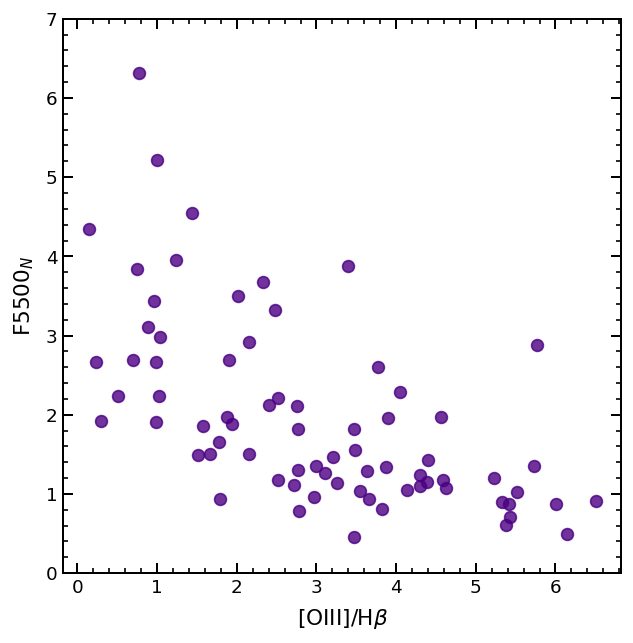

In [59]:
plt.scatter(df_best['LOIII/LHb'], df_best['flux_mean_5500'], s=50, alpha=0.8, c='indigo')
plt.xlabel(r"[OIII]/H$\beta$")
plt.ylabel(r"F5500$_{N}$")
plt.ylim(0,7)
plt.show()

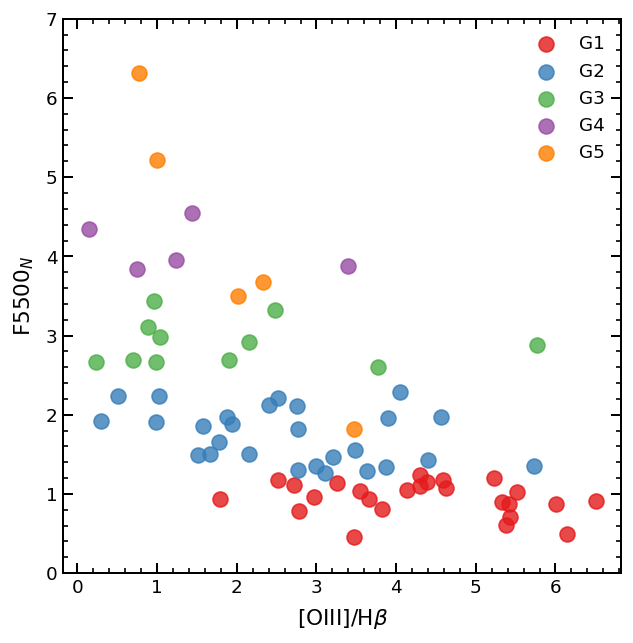

In [60]:

fig, ax = plt.subplots()

for grupo, cor in colors.items():

    mask = df_best["grupos"] == grupo

    ax.scatter(
        df_best.loc[mask, 'LOIII/LHb'],   # substitua pelas suas colunas
        df_best.loc[mask, 'flux_mean_5500'],
        color=cor,
        label=grupo,
        s=80,
        alpha=0.8
    )

plt.xlabel(r"[OIII]/H$\beta$")
plt.ylabel(r"F5500$_{N}$")
plt.ylim(0,7)
ax.legend()

plt.show()

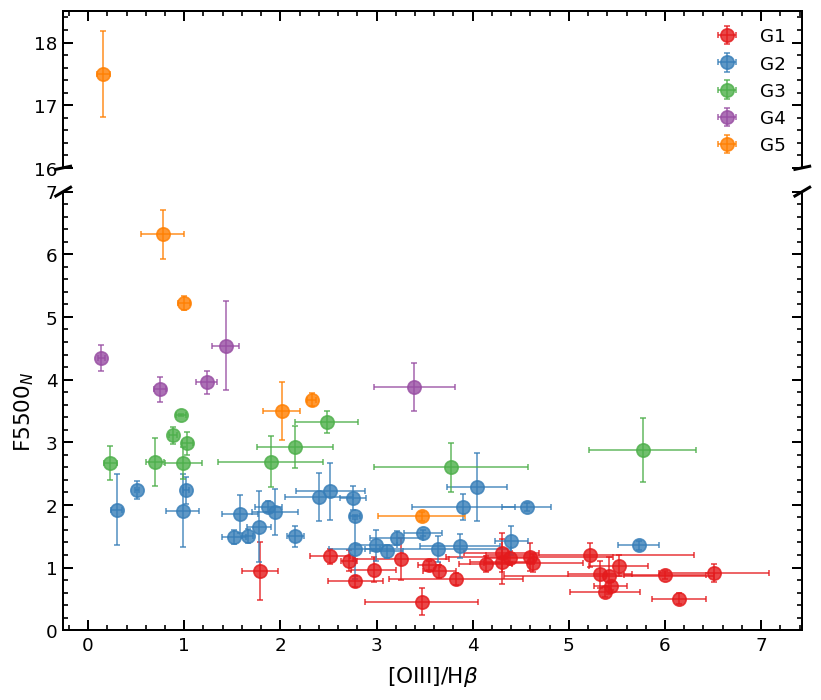

In [61]:

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(7, 6),
    gridspec_kw={'height_ratios': [2.5, 7]}  # 👈 topo menor
)

for grupo, cor in colors.items():
    mask = df_best["grupos"] == grupo

    x = df_best.loc[mask, 'LOIII/LHb']
    y = df_best.loc[mask, 'flux_mean_5500']


    xerr = df_best.loc[mask, 'LOIII/LHb_sigma']
    yerr = df_best.loc[mask, 'err_mean_5500']
    
    # topo
    ax1.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        label=grupo
    )

    # base
    ax2.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        
    )

# limites do eixo y (ajuste conforme quiser)
ax1.set_ylim(16, 18.5)   # parte do outlier
ax2.set_ylim(0, 7)     # distribuição principal

# remove spines para efeito visual
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# topo: remove ticks inferiores (major + minor)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# base: remove ticks superiores (major + minor)
ax2.tick_params(axis='x', which='both', top=False, labeltop=False)

# remove ticks duplicados
ax1.tick_params(labelbottom=False)

# desenha as "quebras"
d = .01
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# labels (coloque só no de baixo para ficar limpo)
ax2.set_xlabel(r"[OIII]/H$\beta$")
ax2.set_ylabel(r"F5500$_{N}$")

ax1.legend()


plt.tight_layout()
plt.subplots_adjust(hspace=0.08)

#fig.savefig("Figuras/oiii_hb_flux5500.pdf", bbox_inches='tight')

plt.show()

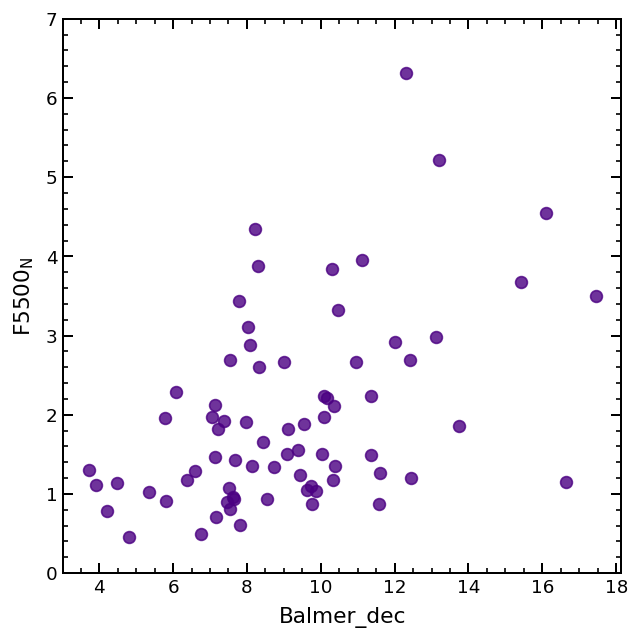

In [62]:
plt.scatter(df_best['Balmer_dec_total_2'], df_best['flux_mean_5500'], s=50, alpha=0.8, c='indigo')
plt.xlabel(r"Balmer_dec")
plt.ylabel(r"$\rm F5500_{N}$")
plt.ylim(0,7)
plt.show()

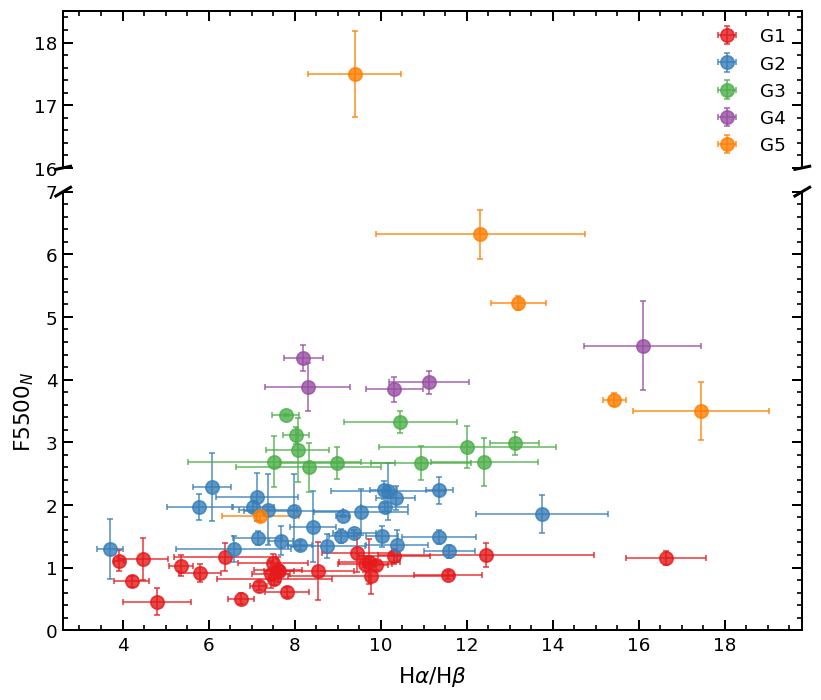

In [63]:
## F5500 vs Balmer_dec com erro

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(7, 6),
    gridspec_kw={'height_ratios': [2.5, 7]}  # 👈 topo menor
)

for grupo, cor in colors.items():
    mask = df_best["grupos"] == grupo

    x = df_best.loc[mask, 'Balmer_dec_total_2']
    y = df_best.loc[mask, 'flux_mean_5500']


    xerr = df_best.loc[mask, 'Balmer_dec_sigma']
    yerr = df_best.loc[mask, 'err_mean_5500']
    
    # topo
    ax1.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        label=grupo
    )

    # base
    ax2.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        
    )

# limites do eixo y (ajuste conforme quiser)
ax1.set_ylim(16, 18.5)   # parte do outlier
ax2.set_ylim(0, 7)     # distribuição principal

# remove spines para efeito visual
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# topo: remove ticks inferiores (major + minor)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# base: remove ticks superiores (major + minor)
ax2.tick_params(axis='x', which='both', top=False, labeltop=False)

# remove ticks duplicados
ax1.tick_params(labelbottom=False)

# desenha as "quebras"
d = .01
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# labels (coloque só no de baixo para ficar limpo)
ax2.set_xlabel(r"H$\alpha$/H$\beta$")
ax2.set_ylabel(r"F5500$_{N}$")

ax1.legend()


plt.tight_layout()
plt.subplots_adjust(hspace=0.08)

#fig.savefig("Figuras/ha_hb_flux5500.pdf", bbox_inches='tight')

plt.show()

In [64]:
df_best

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,...,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id,grupos,grupo_num,LHa_sigma,Balmer_dec_sigma,LOIII_5007_sigma,logL_5100_sigma,LHb_sigma,LOIII/LHb_sigma
0,capers-cos07-v4_prism-clear_6368_43711.spec.fits,4.420440,True,2.558633e-20,0.3446,0.3646,None,0.112426,0.113576,1.352901,0.070525,2.553056,0.324329,19.183270,6368,43711,capers-cos07-v4,150.102626,2.249597,4.420440,0,None,None,None,None,...,5.704230e+42,5.758590e+42,5.815786e+42,5.851865e+42,4.000264e+42,4.019672e+42,4.056132e+42,4.091591e+42,4.115029e+42,43.481062,43.483708,43.488320,43.492315,43.494988,7.081596e+41,5.727709,"(None, capers-cos07-v4_prism-clear_6368_43711....",G2,2,5.577798e+40,0.284470,3.595942e+40,0.004304,2.570527e+40,0.214020
1,capers-cos10-v4_prism-clear_6368_30440.spec.fits,3.504500,True,2.121960e-20,0.3446,0.3646,None,0.168478,0.167391,0.606580,0.084704,2.289896,0.544384,7.161179,6368,30440,capers-cos10-v4,150.120910,2.317934,3.504500,0,None,None,None,None,...,2.852278e+42,2.897211e+42,2.936573e+42,2.959784e+42,1.940875e+42,1.963981e+42,1.990381e+42,2.024247e+42,2.040635e+42,42.756647,42.766660,42.782421,42.802235,42.829114,3.703710e+41,5.374020,"(None, capers-cos10-v4_prism-clear_6368_30440....",G1,1,4.214747e+40,0.504815,3.013270e+40,0.017788,2.450131e+40,0.364700
2,capers-cos10-v4_prism-clear_6368_32659.spec.fits,4.442170,True,5.286217e-21,0.3446,0.3646,None,0.723837,0.728100,1.298028,0.477611,3.801106,1.813420,2.717754,6368,32659,capers-cos10-v4,150.124025,2.306827,4.442170,0,None,None,None,None,...,7.631289e+41,7.921145e+41,8.178681e+41,8.344853e+41,5.652777e+41,5.749388e+41,5.919181e+41,6.089187e+41,6.220264e+41,42.806856,42.823930,42.844624,42.867724,42.887727,2.134758e+41,2.772764,"(None, capers-cos10-v4_prism-clear_6368_32659....",G2,2,2.736957e+40,0.308626,1.698996e+40,0.021897,1.922701e+40,0.262108
3,capers-cos19-v4_prism-clear_6368_4771.spec.fits,5.927350,True,4.012379e-21,0.3446,0.3646,None,0.719158,0.711326,1.654603,0.564374,3.092577,1.721817,2.931750,6368,4771,capers-cos19-v4,150.161029,2.465804,5.927350,0,None,None,None,None,...,6.100056e+42,6.192903e+42,6.303222e+42,6.357122e+42,1.246757e+42,1.271856e+42,1.304910e+42,1.339891e+42,1.361390e+42,43.129767,43.145293,43.162038,43.180440,43.189226,7.343895e+41,1.776863,"(None, capers-cos19-v4_prism-clear_6368_4771.s...",G2,2,1.015832e+41,0.540349,3.401729e+40,0.017573,4.857532e+40,0.126327
4,capers-cos19-v4_prism-clear_6368_9226.spec.fits,3.724103,True,6.832514e-20,0.3446,0.3646,None,0.115676,0.119074,0.878248,0.066626,2.020107,0.347027,13.181830,6368,9226,capers-cos19-v4,150.175938,2.432430,3.724103,0,None,None,None,None,...,1.209660e+43,1.228081e+43,1.247075e+43,1.259925e+43,6.222170e+42,6.279176e+42,6.369545e+42,6.459206e+42,6.515543e+42,43.595210,43.599419,43.605356,43.611473,43.615556,1.061352e+42,6.001349,"(None, capers-cos19-v4_prism-clear_6368_9226.s...",G1,1,1.870777e+41,0.792044,9.001514e+40,0.006027,7.442825e+40,0.429311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uncover-v4_prism-clear_2561_28876.spec.fits,7.036244,True,4.462341e-21,0.3446,0.3646,None,0.541543,0.530911,1.924363,0.571780,2.857349,1.260600,3.365564,2561,28876,uncover-v4,3.569597,-30.373223,7.036244,0,None,None,None,None,...,2.932661e+42,3.088474e+42,3.276416e+42,3.447768e+42,8.977127e+40,1.052825e+41,1.242843e+41,1.451519e+41,1.577188e+41,43.402181,43.410594,43.422311,43.432199,43.438407,4.183113e+41,0.297110,"(None, uncover-v4_pris

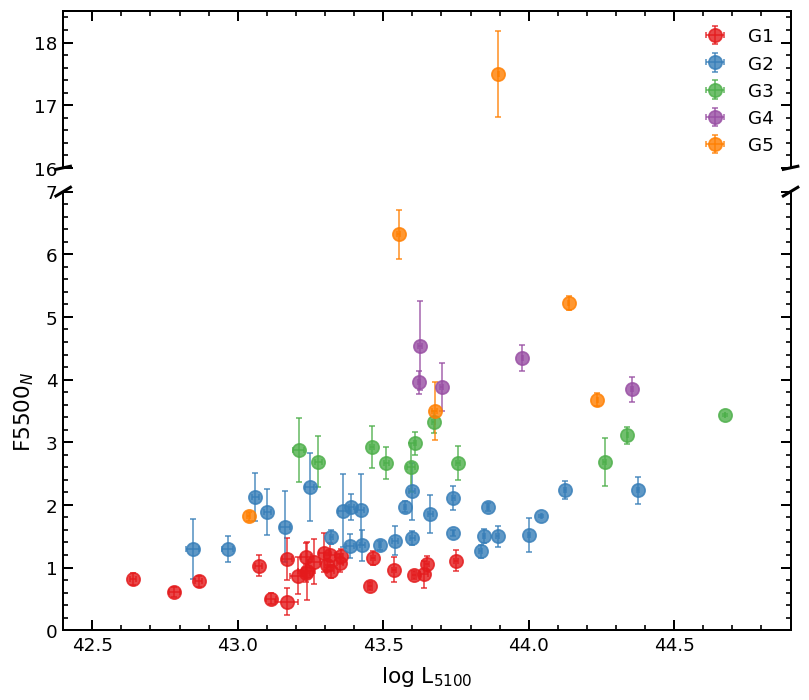

In [65]:
## F5500 vs L5100 com erro

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(7, 6),
    gridspec_kw={'height_ratios': [2.5, 7]}  # 👈 topo menor
)

for grupo, cor in colors.items():
    mask = df_best["grupos"] == grupo

    x = df_best.loc[mask, 'logL_5100_2']
    y = df_best.loc[mask, 'flux_mean_5500']


    xerr = df_best.loc[mask, 'logL_5100_sigma']
    yerr = df_best.loc[mask, 'err_mean_5500']
    
    # topo
    ax1.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        label=grupo
    )

    # base
    ax2.errorbar(
        x, y,
        xerr=xerr, yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        
    )

# limites do eixo y (ajuste conforme quiser)
ax1.set_ylim(16, 18.5)   # parte do outlier
ax2.set_ylim(0, 7)     # distribuição principal

# remove spines para efeito visual
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# topo: remove ticks inferiores (major + minor)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# base: remove ticks superiores (major + minor)
ax2.tick_params(axis='x', which='both', top=False, labeltop=False)

# remove ticks duplicados
ax1.tick_params(labelbottom=False)

# desenha as "quebras"
d = .01
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# labels (coloque só no de baixo para ficar limpo)
ax2.set_xlabel(r"log L$_{5100}$")
ax2.set_ylabel(r"F5500$_{N}$")

ax1.legend()


plt.tight_layout()
plt.subplots_adjust(hspace=0.08)
plt.xticks(np.arange(42.5, 45.5, 0.5))
plt.xlim(42.4, 44.9)

#fig.savefig("Figuras/l5100_flux5500.pdf", bbox_inches='tight')

plt.show()

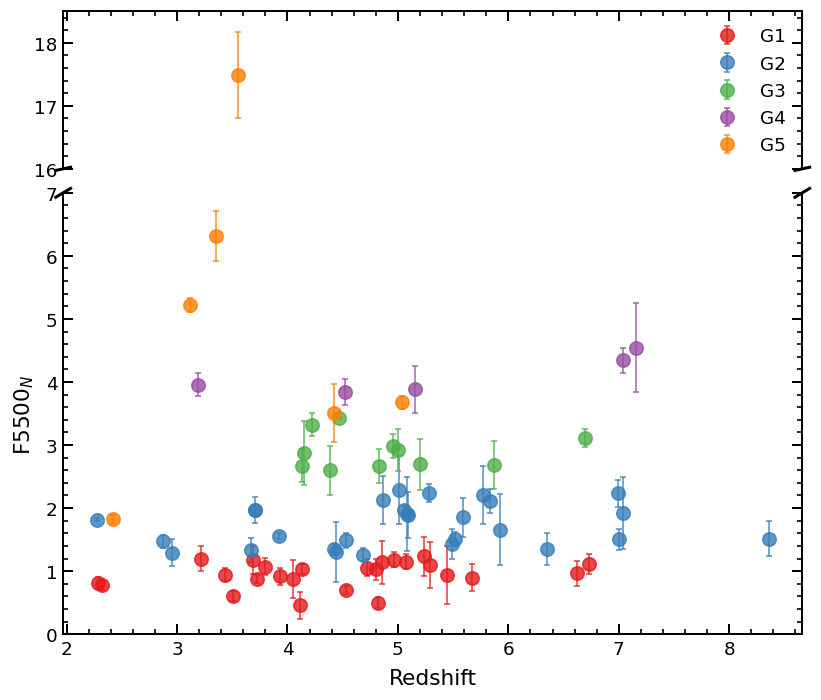

In [66]:
## F5500 vs z com erro

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(7, 6),
    gridspec_kw={'height_ratios': [2.5, 7]}  # 👈 topo menor
)

for grupo, cor in colors.items():
    mask = df_best["grupos"] == grupo

    x = df_best.loc[mask, 'z']
    y = df_best.loc[mask, 'flux_mean_5500']


    yerr = df_best.loc[mask, 'err_mean_5500']
    
    # topo
    ax1.errorbar(
        x, y,
        yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        label=grupo
    )

    # base
    ax2.errorbar(
        x, y,
        yerr=yerr,
        fmt='o',
        color=cor,
        ms=8,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        
    )

# limites do eixo y (ajuste conforme quiser)
ax1.set_ylim(16, 18.5)   # parte do outlier
ax2.set_ylim(0, 7)     # distribuição principal

# remove spines para efeito visual
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

# topo: remove ticks inferiores (major + minor)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# base: remove ticks superiores (major + minor)
ax2.tick_params(axis='x', which='both', top=False, labeltop=False)

# remove ticks duplicados
ax1.tick_params(labelbottom=False)

# desenha as "quebras"
d = .01
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# labels (coloque só no de baixo para ficar limpo)
ax2.set_xlabel("Redshift")
ax2.set_ylabel(r"F5500$_{N}$")

ax1.legend()


plt.tight_layout()
plt.subplots_adjust(hspace=0.08)
#plt.xticks(np.arange(42.5, 45.5, 0.5))
#plt.xlim(42.4, 44.9)

#fig.savefig("Figuras/z_flux5500.pdf", bbox_inches='tight')

plt.show()

/tmp/ipykernel_9447/473541214.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


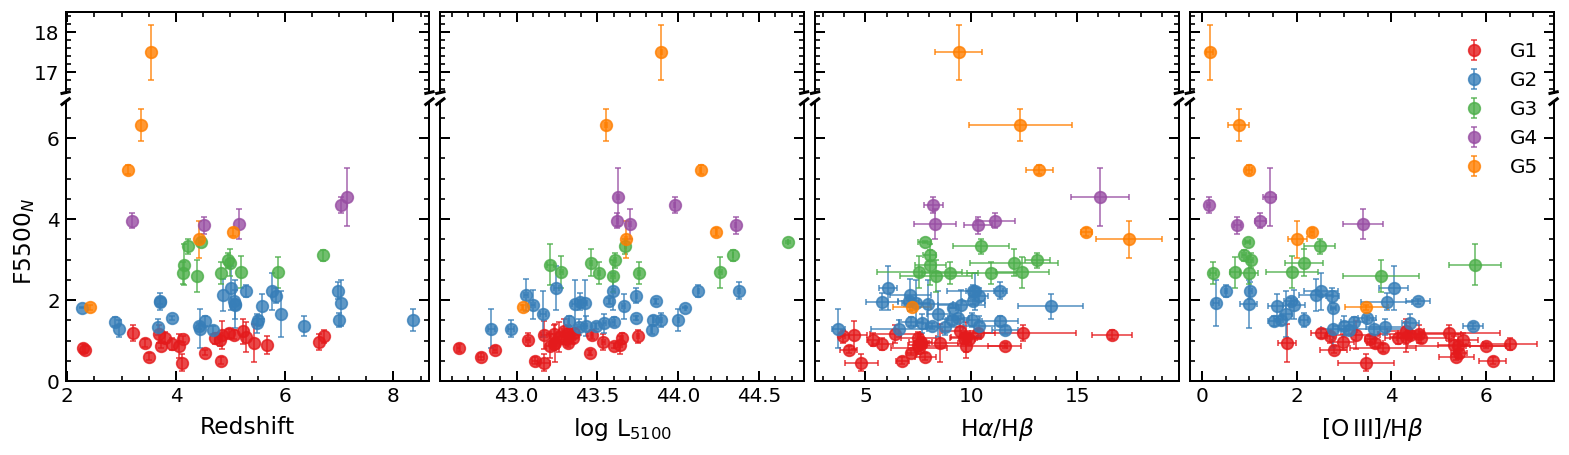

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# parâmetros
# -------------------------
ncols = 4

fig = plt.figure(figsize=(16,4))

outer_gs = fig.add_gridspec(1, ncols, wspace=0.03)

# 👉 aqui você define as variáveis de x (substitua depois)
x_vars = ['z', 'logL_5100_2', 'Balmer_dec_total_2', 'LOIII/LHb']  # <-- TROCAR
x_labels = ["Redshift", r"log L$_{5100}$", r"H$\alpha$/H$\beta$", r"[O$\,$III]/H$\beta$"]  # <-- TROCAR
x_err_vars = [
    None,                 # painel 1 (sem erro)
    'logL_5100_sigma',             # painel 2
    'Balmer_dec_sigma',             # painel 3
    'LOIII/LHb_sigma'                  # painel 4
]

axes_bottom = []

for i in range(ncols):

    # subgrid para cada painel (topo + base)
    gs = outer_gs[i].subgridspec(
        2, 1,
        height_ratios=[2, 6.9],
        hspace=0.05
    )

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    axes_bottom.append(ax2)

    xcol = x_vars[i]

    # -------------------------
    # loop nos grupos
    # -------------------------
    for grupo, cor in colors.items():
        mask = df_best["grupos"] == grupo

        x = df_best.loc[mask, xcol]
        y = df_best.loc[mask, 'flux_mean_5500']
        yerr = df_best.loc[mask, 'err_mean_5500']

        # --- erro em x ---
        if x_err_vars[i] is not None:
            xerr = df_best.loc[mask, x_err_vars[i]]
        else:
            xerr = None

        ax1.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt='o',
            color=cor,
            ms=7,
            alpha=0.8,
            capsize=2,
            elinewidth=1
        )
        ax2.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', color=cor,
                     ms=7, alpha=0.8, capsize=2, elinewidth=1,
                     label=grupo if i == 0 else None)

    # -------------------------
    # limites
    # -------------------------
    ax1.set_ylim(16.5, 18.5)
    ax2.set_ylim(0, 6.9)

    # -------------------------
    # estética quebra
    # -------------------------
    ax1.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax2.tick_params(axis='x', which='both', top=False)

    # só primeiro painel tem eixo y
    if i != 0:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    # -------------------------
    # desenha quebra
    # -------------------------
    d = .01
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-d, +d), (-d, +d), **kwargs)
    ax1.plot((1-d, 1+d), (-d, +d), **kwargs)

    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    # -------------------------
    # labels
    # -------------------------
    ax2.set_xlabel(x_labels[i])

# eixo y só no primeiro
axes_bottom[0].set_ylabel(r"F5500$_{N}$")

# legenda global (melhor que repetir)
#axes_bottom[3].legend(frameon=False)
#ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.87, 0.855),
    #ncol=5,
    frameon=False
)

plt.tight_layout()
fig.savefig("Figuras/painel_f5500.pdf", bbox_inches='tight')


plt.show()

/tmp/ipykernel_9447/1631113209.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


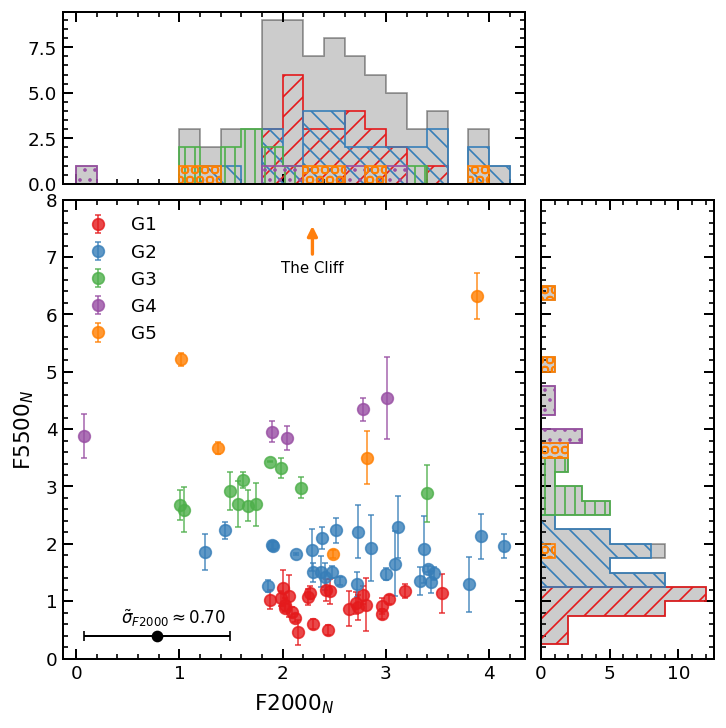

In [68]:
# -------------------------
# figura com GridSpec
# -------------------------
fig = plt.figure(figsize=(7,7))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=(4, 1.5),
    height_ratios=(1.5, 4),
    hspace=0.05,
    wspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])  # topo
ax_scatter = fig.add_subplot(gs[1, 0])  # principal
ax_histy = fig.add_subplot(gs[1, 1])  # direita

# --- filtro global (mesmo corte do scatter) ---
y_max = 10 ## retirando o the cliff

mask_global = df_best['flux_mean_5500'] < y_max

x_all = df_best.loc[mask_global, 'flux_mean_2000']
y_all = df_best.loc[mask_global, 'flux_mean_5500']

# --- erro mediano do fluxo em 2000 A
xerr_mean = np.nanmedian(df_best.loc[mask_global, 'err_mean_2000'])

# -------------------------
# loop nos grupos
# -------------------------
hatches = ['//', '\\\\', '||', '..', 'OO',  '**']
indice = 0
for grupo, cor in colors.items():
    mask = df_best["grupos"] == grupo

    x = df_best.loc[mask, 'flux_mean_2000']
    y = df_best.loc[mask, 'flux_mean_5500']

    yerr = df_best.loc[mask, 'err_mean_5500']
    xerr = df_best.loc[mask, 'err_mean_2000']  # se tiver

    # --- scatter com erro ---
    ax_scatter.errorbar(
        x, y,
        xerr=None,        # coloque xerr se quiser
        yerr=yerr,
        fmt='o',
        color=cor,
        ms=7,
        alpha=0.8,
        capsize=2,
        elinewidth=1,
        label=grupo
    )

    # --- histogramas ---
    ax_histx.hist(
        x,
        bins=np.linspace(0, 5, 26),
        color=cor,
        alpha=1,
        histtype='step',
        hatch = hatches[indice]
    )

    ax_histy.hist(
        y,
        bins = np.arange(0, 8.25, 0.25),
        orientation='horizontal',
        color=cor,
        alpha=1,
        histtype='step',
        hatch = hatches[indice]
    )

    indice = indice + 1

# topo (x)
ax_histx.hist(
    x_all,
    bins=np.linspace(0, 5, 26),
    color='gray',
    alpha=0.4,
    edgecolor='black',
    histtype='stepfilled'
)

# direita (y)
ax_histy.hist(
    y_all,
    bins=np.arange(0, 8.25, 0.25),
    orientation='horizontal',
    color='gray',
    alpha=0.4,
    edgecolor='black',
    histtype='stepfilled'
)

# -------------------------
# estética
# -------------------------

#limite no eixo y
ax_scatter.set_ylim(0, 8)
ax_histy.set_ylim(0, 8)


# remove labels duplicados
ax_histx.tick_params(axis='x', labelbottom=False)
ax_histy.tick_params(axis='y', labelleft=False)

# labels principais
ax_scatter.set_xlabel(r"F2000$_N$")
ax_scatter.set_ylabel(r"F5500$_N$")

# alinhar limites
ax_histx.set_xlim(ax_scatter.get_xlim())
#ax_histy.set_ylim(ax_scatter.get_ylim())

# legenda
ax_scatter.legend(frameon=False)

# ------------------
# erro médio em f2000
# ------------------

# posição no canto (ajuste fino aqui)
x_ref = 0.18 * ax_scatter.get_xlim()[1]
y_ref = 0.05 * ax_scatter.get_ylim()[1]

ax_scatter.errorbar(
    x_ref, y_ref,
    xerr=xerr_mean,
    yerr=None,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1.2
)

# label do erro
ax_scatter.text(
    x_ref-0.35,
    y_ref+0.12,
    rf"$\tilde{{\sigma}}_{{F2000}} \approx {xerr_mean:.2f}$",
    fontsize=10,
    ha='left',
    va='bottom'
)

# ------------------
# adicionando The Cliff
# ------------------

# posição do objeto
x_cliff = 2.288155
y_cliff_true = 17.489988

# limite do eixo (onde a seta vai começar)
y_top = (ax_scatter.get_ylim()[1])*0.95

# posição onde a seta começa (um pouco abaixo do topo)
y_arrow_start = y_top * 0.92

# --- seta apontando para cima ---
ax_scatter.annotate(
    '',
    xy=(x_cliff, y_top),              # ponta da seta (topo do eixo)
    xytext=(x_cliff, y_arrow_start),  # base da seta
    arrowprops=dict(
        arrowstyle='-|>',
        color='tab:orange',
        lw=2
    )
)

# --- anotação ---
ax_scatter.text(
    x_cliff,
    y_arrow_start - 0.05,
    "The Cliff",
    ha='center',
    va='top',
    fontsize=9
)

plt.tight_layout()
#fig.savefig("Figuras/f2000_f5500.pdf", bbox_inches='tight')
plt.show()

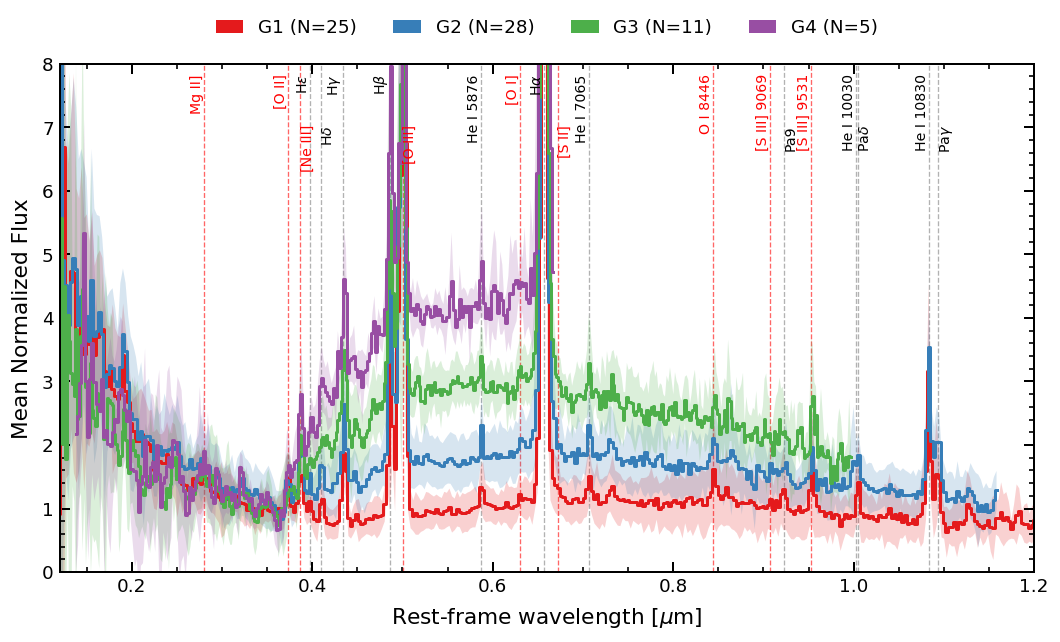

In [69]:
lines_group = {
            #r"Ly$\alpha$": 0.121567,
            #r"N V": 0.1240,
            #r"Si IV": 0.140277,
            #r"C IV": 0.1549,
            #r"He II": 0.1640,
            #r"C III]": 0.1909,
            r"Mg II]": 0.2800,
            r"[O II]": 0.3727,
            r"[Ne III]": 0.386876,
            r"H$\epsilon$": 0.3970079,
            r"H$\delta$": 0.4101742,
            r"H$\gamma$": 0.4340471,
            r"H$\beta$": 0.48613,
            r"[O III]": 0.5006843,
            r"He I 5876": 0.5875624,
            r"[O I]": 0.6300,
            r"H$\alpha$": 0.6563,
            r"[S II]": 0.6723,
            r"He I 7065": 0.7065,
            r"O I 8446": 0.8446,
            r"[S III] 9069": 0.90686,
            r"Pa9": 0.9229014,
            r"[S III] 9531": 0.95311,
            r"He I 10030": 1.0030,
            r"Pa$\delta$": 1.0049,
            r"He I 10830": 1.0830,
            r"Pa$\gamma$": 1.0938,
        }

fig, ax = plot_overlaid_mean_spectra(
    mean_specs,
    offset=False,
    lines=lines_group,
    figsize=(9,6),
    min_contrib=5,
    ylim=(0,8),
    xlim=(0.12,1.2),
    colors=colors,
    show_std=True,
)

fig.savefig("Figuras/mean_flux_groups.pdf", bbox_inches='tight')

[(np.str_('uncover-61-v4_prism-clear_2561_20698.spec.fits'), 2.417316), (np.str_('rubies-uds1-v4_prism-clear_4233_40579.spec.fits'), 3.113558), (np.str_('rubies-uds23-v4_prism-clear_4233_144195.spec.fits'), 3.3547552), (np.str_('rubies-uds31-v4_prism-clear_4233_154183.spec.fits'), 3.548925327627479), (np.str_('nexus-obs5-v4_prism-clear_5105_2314.spec.fits'), 4.42207), (np.str_('jades-gdn198-v4_prism-clear_1181_68797.spec.fits'), 5.0410485)]
[(np.str_('uncover-61-v4_prism-clear_2561_20698.spec.fits'), 2.417316), (np.str_('rubies-uds23-v4_prism-clear_4233_144195.spec.fits'), 3.3547552), (np.str_('rubies-uds1-v4_prism-clear_4233_40579.spec.fits'), 3.113558), (np.str_('nexus-obs5-v4_prism-clear_5105_2314.spec.fits'), 4.42207), (np.str_('jades-gdn198-v4_prism-clear_1181_68797.spec.fits'), 5.0410485), (np.str_('rubies-uds31-v4_prism-clear_4233_154183.spec.fits'), 3.548925327627479)]


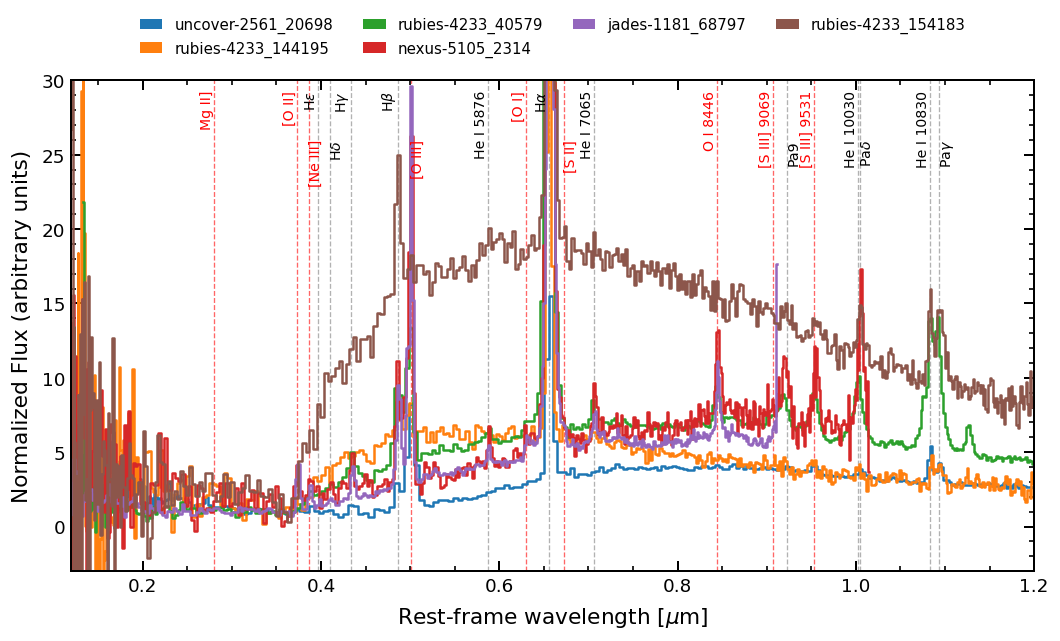

In [70]:
print(g5_zip_zsorted)

indices = [0,2,1,4,5,3]
reordenado = [g5_zip_zsorted[i] for i in indices]
print(reordenado)


lines = {
            #r"Ly$\alpha$": 0.121567,
            #r"N V": 0.1240,
            #r"Si IV": 0.140277,
            #r"C IV": 0.1549,
            #r"He II": 0.1640,
            #r"C III]": 0.1909,
            r"Mg II]": 0.2800,
            r"[O II]": 0.3727,
            r"[Ne III]": 0.386876,
            r"H$\epsilon$": 0.3970079,
            r"H$\delta$": 0.4101742,
            r"H$\gamma$": 0.4340471,
            r"H$\beta$": 0.48613,
            r"[O III]": 0.5006843,
            r"He I 5876": 0.5875624,
            r"[O I]": 0.6300,
            r"H$\alpha$": 0.6563,
            r"[S II]": 0.6723,
            r"He I 7065": 0.7065,
            r"O I 8446": 0.8446,
            r"[S III] 9069": 0.90686,
            r"Pa9": 0.9229014,
            r"[S III] 9531": 0.95311,
            r"He I 10030": 1.0030,
            r"Pa$\delta$": 1.0049,
            r"He I 10830": 1.0830,
            r"Pa$\gamma$": 1.0938,
        }

fig = plot_overlaid_spectra(
    reordenado,
    indices=range(0, 6),
    figsize=(9,6),
    offset=False,
    lines=lines,
    loader_kwargs=dict(
        input_flux_unit="uJy",
        wave_unit="um",
        restframe=True,
        normalize=True,
        norm_window = (0.3446, 0.3646),
    ),
    xlim=(0.12, 1.2),
    ylim=(-3,30)
)
fig.savefig("Figuras/outliers_no_offset.pdf", bbox_inches='tight')
plt.show()

In [71]:
df_best[df_best['flux_mean_5500'].between(6,18) ]

,file,z,normalized,norm_factor,norm_window_min,norm_window_max,norm_error,err_norm_mean,err_norm_median,flux_mean_5500,err_mean_5500,flux_mean_2000,err_mean_2000,SNR_5500,pid,srcid,root,ra,dec,zspec,Ndup,dup_filenames_0,dup_filenames_1,dup_filenames_2,dup_filenames_3,...,LHa_total_1,LHa_total_2,LHa_total_3,LHa_total_4,LOIII_5007_0,LOIII_5007_1,LOIII_5007_2,LOIII_5007_3,LOIII_5007_4,logL_5100_0,logL_5100_1,logL_5100_2,logL_5100_3,logL_5100_4,LHb_total_2,LOIII/LHb,group_id,grupos,grupo_num,LHa_sigma,Balmer_dec_sigma,LOIII_5007_sigma,logL_5100_sigma,LHb_sigma,LOIII/LHb_sigma
58,rubies-uds23-v4_prism-clear_4233_144195.spec.fits,3.354755,True,1.154061e-20,0.3446,0.3646,None,0.748337,0.724885,6.316134,0.397383,3.880742,2.308169,15.894337,4233,144195,rubies-uds23-v4,34.325156,-5.143685,3.354755,0,None,None,None,None,...,2.537262e+42,2.574081e+42,2.615868e+42,2.641899e+42,1.058763e+41,1.288720e+41,1.620235e+41,1.969353e+41,2.172379e+41,43.543889,43.547674,43.553335,43.558839,43.561766,2.089241e+41,0.775514,"(None, rubies-uds23-v4_prism-clear_4233_144195...",G5,5,3.930270e+40,2.434424,3.403169e+40,0.005582,4.140414e+40,0.223950
62,rubies-uds31-v4_prism-clear_4233_154183.spec.fits,3.548925,True,8.320946e-21,0.3446,0.3646,None,0.893270,0.884429,17.489988,0.686710,2.288155,2.714780,25.469251,4233,154183,rubies-uds31-v4,34.410749,-5.129664,3.548925,0,None,None,None,None,...,6.575987e+42,6.643780e+42,6.704502e+42,6.754432e+42,3.871537e+40,7.096378e+40,1.127314e+41,1.648078e+41,2.030878e+41,43.890463,43.892740,43.895860,43.898783,43.900802,7.069438e+41,0.159463,"(None, rubies-uds31-v4_prism-clear_4233_154183...",G5,5,6.425733e+40,1.088831,4.692203e+40,0.003021,8.219074e+40,0.068914


# Salvando espectro dos outliers

In [72]:
print(g5_zip_zsorted)

[(np.str_('uncover-61-v4_prism-clear_2561_20698.spec.fits'), 2.417316), (np.str_('rubies-uds1-v4_prism-clear_4233_40579.spec.fits'), 3.113558), (np.str_('rubies-uds23-v4_prism-clear_4233_144195.spec.fits'), 3.3547552), (np.str_('rubies-uds31-v4_prism-clear_4233_154183.spec.fits'), 3.548925327627479), (np.str_('nexus-obs5-v4_prism-clear_5105_2314.spec.fits'), 4.42207), (np.str_('jades-gdn198-v4_prism-clear_1181_68797.spec.fits'), 5.0410485)]


In [73]:
def save_spectrum_to_csv(
    fits_path,
    output_csv,
    z=None,
    input_flux_unit="uJy",
    wave_unit="um",
    restframe=True,
    normalize=False,
    norm_window=(0.3446, 0.3646),
    norm_statistic="median",
):
    import pandas as pd

    # --- carrega espectro ---
    spec = load_spectrum(
        fits_path,
        z=z,
        input_flux_unit=input_flux_unit,
        wave_unit=wave_unit,
        restframe=restframe,
        normalize=normalize,
        norm_window=norm_window,
        norm_statistic=norm_statistic,
    )

    # --- dataframe ---
    df = pd.DataFrame({
        "wave": spec["wave"],
        "flux": spec["flux"],
        "err": spec["err"],
    })

    # --- metadados ---
    metadata = {
        "file": spec["file"],
        "z": spec["z"],
        "restframe": restframe,
        "input_flux_unit": input_flux_unit,
        "output_flux_type": "flambda",
        "normalized": spec["normalized"],
        "norm_window": spec["norm_window"],
        "norm_factor": spec["norm_factor"],
    }

    # --- salva com header ---
    with open(output_csv, "w") as f:

        # escreve metadados como comentários
        for key, value in metadata.items():
            f.write(f"# {key}: {value}\n")

        # separador visual
        f.write("# --- data ---\n")

        # escreve dataframe
        df.to_csv(f, index=False)

    return df

In [74]:

output_dir = "spectra_outliers"
os.makedirs(output_dir, exist_ok=True)

for fname, z in g5_zip_zsorted:

    base = os.path.basename(fname).replace(".fits", "_norm.csv")
    output_csv = os.path.join(output_dir, base)

    save_spectrum_to_csv(
        fits_path=f"DeGraaff_espectros/{fname}",
        output_csv=output_csv,
        z=z,
        normalize=True
    )